<a href="https://colab.research.google.com/github/nicoll1920/MHW-Prediccion-Peru/blob/main/proyecto_integrador_mhw_peru_final_corregido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador - Ciencia de Datos Ambientales

## Prediccion de temperatura superficial del mar e identificacion de olas de calor marinas en la costa del Peru (1990-2025)

Este notebook integra el flujo final del proyecto:

1. Definicion del problema ambiental e hipotesis.
2. Ingesta y preparacion de datos NOAA OISST, con integracion opcional de ICEN y ERA5.
3. Analisis exploratorio de la temperatura superficial del mar.
4. Identificacion de olas de calor marinas mediante la metodologia de Hobday et al. (2016) usando SST observada.
5. Division regional en zona Norte, Centro y Sur.
6. Construccion de variables predictoras para estimar SST, incluyendo ICEN rezagado un mes si esta disponible.
7. Entrenamiento 70/30 de Random Forest Regressor con tres configuraciones por zona.
8. Comparacion de desempeno del modelo usando MAE, RMSE y R2.
9. Aplicacion de Hobday sobre la SST predicha para detectar MHW en el periodo de prueba.
10. Comparacion entre MHW observadas y MHW detectadas a partir de SST predicha.

**Nota metodologica:** como se trabaja con series temporales, la division 70/30 se hace en orden cronologico. El primer 70% de los dias se usa para entrenamiento y el 30% final se reserva para prueba. Esto evita mezclar informacion futura dentro del entrenamiento.

## 1. Descripcion del problema ambiental

Las olas de calor marinas (Marine Heatwaves, MHW) son periodos prolongados de temperatura superficial del mar anormalmente alta. En la costa peruana, estos eventos pueden alterar los ecosistemas marinos, afectar procesos de afloramiento, cambiar la disponibilidad de recursos pesqueros y modificar condiciones oceanograficas asociadas a eventos El Nino.

El proyecto busca predecir la temperatura superficial del mar (SST) frente a la costa peruana y, a partir de la SST predicha, aplicar la metodologia de Hobday et al. (2016) para identificar posibles olas de calor marinas.

### Indicadores ambientales clave

| Indicador | Unidad | Uso en el proyecto |
|---|---:|---|
| SST promedio regional/zonal | C | Variable oceanografica principal y variable objetivo del modelo |
| Anomalia climatologica de SST | C | Desviacion frente al comportamiento normal del dia del ano |
| Dias bajo condicion MHW | dias | Frecuencia anual o zonal de MHW |
| Duracion del evento | dias | Persistencia de cada ola de calor marina |
| Intensidad acumulada | C dia | Severidad total del evento |

### Hipotesis de trabajo

1. La SST puede ser estimada a partir de su comportamiento previo, variables estacionales y, si estan disponibles, variables oceanograficas/climaticas complementarias.
2. El desempeno del modelo Random Forest Regressor puede variar entre zona Norte, Centro y Sur debido a diferencias oceanograficas regionales.
3. Al aplicar Hobday sobre la SST predicha, es posible aproximar la ocurrencia de MHW en el periodo de prueba, aunque la deteccion dependera de la precision de la prediccion termica.

## 2. Instalacion y carga de librerias

Ejecutar esta celda en Google Colab. Si ya tienes instaladas las librerias, la instalacion sera rapida.

In [ ]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 3. Arquitectura y flujo de datos

### Fuentes de datos

| Fuente | Formato | Variable principal | Uso |
|---|---|---|---|
| NOAA OISST v2.1 | NetCDF (.nc) | SST diaria | Base para deteccion MHW y variable objetivo del modelo |
| ICEN | CSV | Indice Costero El Nino | Variable explicativa opcional |
| ERA5 | NetCDF (.nc) | Viento u10/v10 | Variable explicativa opcional |

### Pipeline

Carga de datos -> limpieza y validacion -> promedio espacial por zona -> calculo de climatologia y umbral P90 -> deteccion MHW observada -> features predictoras -> prediccion de SST con Random Forest -> aplicacion de Hobday sobre SST predicha -> comparacion de detecciones -> conclusiones.

## 4. Conexion a Google Drive y rutas

Ajusta `BASE` si tus archivos estan en otra carpeta. El notebook funciona principalmente con NOAA OISST. ICEN y ERA5 se integran solo si existen en las rutas indicadas.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
BASE = Path('/content/drive/MyDrive/DATOS_PROYECTO')

RUTA_NOAA = BASE / 'NOAA_OISST_PERU_RECORTADO_1990_2025'
RUTA_ICEN = BASE / 'ICEN' / 'ICEN_1990_2025.csv'
RUTA_ERA5_U = BASE / 'ERA5' / 'data_viento_u.nc'
RUTA_ERA5_V = BASE / 'ERA5' / 'data_viento_v.nc'

OUT_DIR = BASE / 'RESULTADOS_INTEGRADOR_FINAL'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Rutas configuradas:')
print('NOAA :', RUTA_NOAA)
print('ICEN :', RUTA_ICEN, '| existe:', RUTA_ICEN.exists())
print('ERA5 U:', RUTA_ERA5_U, '| existe:', RUTA_ERA5_U.exists())
print('ERA5 V:', RUTA_ERA5_V, '| existe:', RUTA_ERA5_V.exists())
print('Salida:', OUT_DIR)

Rutas configuradas:
NOAA : /content/drive/MyDrive/DATOS_PROYECTO/NOAA_OISST_PERU_RECORTADO_1990_2025
ICEN : /content/drive/MyDrive/DATOS_PROYECTO/ICEN/ICEN_1990_2025.csv | existe: True
ERA5 U: /content/drive/MyDrive/DATOS_PROYECTO/ERA5/data_viento_u.nc | existe: True
ERA5 V: /content/drive/MyDrive/DATOS_PROYECTO/ERA5/data_viento_v.nc | existe: True
Salida: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL


## 5. Carga y preparacion de NOAA OISST

Se cargan los archivos mensuales `.nc`, se calcula la SST promedio para tres zonas latitudinales y tambien para el total del dominio peruano.

Zonas propuestas:

| Zona | Rango latitudinal aproximado |
|---|---|
| Norte | 0 a 6 S |
| Centro | 6 S a 13 S |
| Sur | 13 S a 20 S |

In [ ]:
archivos_noaa = sorted(glob.glob(str(RUTA_NOAA / 'oisst_peru_sst_*.nc')))

print('Total de archivos NOAA encontrados:', len(archivos_noaa))
if archivos_noaa:
    print('Primer archivo:', os.path.basename(archivos_noaa[0]))
    print('Ultimo archivo:', os.path.basename(archivos_noaa[-1]))

if len(archivos_noaa) == 0:
    raise FileNotFoundError('No se encontraron archivos NOAA. Revisa RUTA_NOAA.')
if len(archivos_noaa) != 432:
    print('Aviso: para 1990-2025 completos se esperaban 432 archivos mensuales.')

Total de archivos NOAA encontrados: 432
Primer archivo: oisst_peru_sst_199001.nc
Ultimo archivo: oisst_peru_sst_202512.nc


In [ ]:
def detectar_variable_sst(ds):
    nombres_preferidos = ['sst', 'SST', 'sea_surface_temperature', 'analysed_sst', 'temperature']
    for nombre in nombres_preferidos:
        if nombre in ds.data_vars:
            return nombre
    for nombre, da in ds.data_vars.items():
        if np.issubdtype(da.dtype, np.number) and any('time' in d.lower() for d in da.dims):
            return nombre
    for nombre, da in ds.data_vars.items():
        if np.issubdtype(da.dtype, np.number):
            return nombre
    raise ValueError('No se pudo detectar una variable numerica de SST.')


def detectar_dim_tiempo(da):
    for d in da.dims:
        if d.lower() in ['time', 't', 'valid_time'] or 'time' in d.lower():
            return d
    raise ValueError(f'No se pudo detectar la dimension temporal en dims={da.dims}')


def convertir_a_celsius(da):
    units = str(da.attrs.get('units', '')).lower()
    if 'kelvin' in units or units == 'k':
        return da - 273.15
    try:
        if float(da.mean(skipna=True).values) > 100:
            return da - 273.15
    except Exception:
        pass
    return da


def detectar_dim_lat_lon(da):
    lat_candidates = [d for d in da.dims if d.lower() in ['lat', 'latitude']]
    lon_candidates = [d for d in da.dims if d.lower() in ['lon', 'longitude']]
    if not lat_candidates or not lon_candidates:
        raise ValueError(f'No se detectaron dimensiones lat/lon en dims={da.dims}')
    return lat_candidates[0], lon_candidates[0]


ZONAS = {
    'Peru_total': None,
    'Norte':  {'lat_min': -6,  'lat_max': 0},
    'Centro': {'lat_min': -13, 'lat_max': -6},
    'Sur':    {'lat_min': -20, 'lat_max': -13},
}


def seleccionar_por_lat(da, lat_dim, lat_min, lat_max):
    lat_vals = da[lat_dim].values
    if lat_vals[0] <= lat_vals[-1]:
        return da.sel({lat_dim: slice(lat_min, lat_max)})
    return da.sel({lat_dim: slice(lat_max, lat_min)})


def leer_promedios_zonales_nc(ruta):
    ds = xr.open_dataset(ruta)
    var_sst = detectar_variable_sst(ds)
    da = convertir_a_celsius(ds[var_sst])
    dim_t = detectar_dim_tiempo(da)
    dim_lat, dim_lon = detectar_dim_lat_lon(da)

    resultados = []
    for zona, lim in ZONAS.items():
        if lim is None:
            sub = da
        else:
            sub = seleccionar_por_lat(da, dim_lat, lim['lat_min'], lim['lat_max'])

        dims_espaciales = [d for d in sub.dims if d != dim_t]
        serie = sub.mean(dim=dims_espaciales, skipna=True)
        df = serie.to_dataframe(name='sst_promedio').reset_index()
        if dim_t != 'time':
            df = df.rename(columns={dim_t: 'time'})
        df['fecha'] = pd.to_datetime(df['time']).dt.floor('D')
        df['zona'] = zona
        resultados.append(df[['fecha', 'zona', 'sst_promedio']])

    ds.close()
    return pd.concat(resultados, ignore_index=True)

In [ ]:
series = []
for f in tqdm(archivos_noaa, desc='Leyendo NOAA por zonas'):
    series.append(leer_promedios_zonales_nc(f))

df_sst_zonas = (
    pd.concat(series, ignore_index=True)
    .groupby(['fecha', 'zona'], as_index=False)['sst_promedio'].mean()
    .sort_values(['zona', 'fecha'])
    .reset_index(drop=True)
)

df_sst_zonas['anio'] = df_sst_zonas['fecha'].dt.year

display(df_sst_zonas.head())
print('Rango:', df_sst_zonas['fecha'].min().date(), 'a', df_sst_zonas['fecha'].max().date())
print('Zonas:', df_sst_zonas['zona'].unique())
print('Registros por zona:')
print(df_sst_zonas['zona'].value_counts().sort_index())

Leyendo NOAA por zonas:   0%|          | 0/432 [00:00<?, ?it/s]

,fecha,zona,sst_promedio,anio
0,1990-01-01,Centro,22.964834,1990
1,1990-01-02,Centro,23.048344,1990
2,1990-01-03,Centro,23.098583,1990
3,1990-01-04,Centro,23.090693,1990
4,1990-01-05,Centro,23.121454,1990


Rango: 1990-01-01 a 2025-12-31
Zonas: ['Centro' 'Norte' 'Peru_total' 'Sur']
Registros por zona:
zona
Centro        13149
Norte         13149
Peru_total    13149
Sur           13149
Name: count, dtype: int64


In [ ]:
# Validacion de continuidad temporal por zona
for zona, sub in df_sst_zonas.groupby('zona'):
    fechas_esperadas = pd.date_range(sub['fecha'].min(), sub['fecha'].max(), freq='D')
    faltantes = fechas_esperadas.difference(sub['fecha'])
    print(f'{zona:10s} | dias={len(sub):5d} | faltantes={len(faltantes)}')

Centro     | dias=13149 | faltantes=0
Norte      | dias=13149 | faltantes=0
Peru_total | dias=13149 | faltantes=0
Sur        | dias=13149 | faltantes=0


## 6. Carga opcional de ICEN y ERA5

Estas fuentes no son obligatorias para que el modelo funcione. Si los archivos no existen, el notebook continua solo con variables derivadas de SST.

In [ ]:
def cargar_icen(ruta):
    if not Path(ruta).exists():
        print('ICEN no encontrado. Se continuara sin ICEN.')
        return None

    icen = pd.read_csv(ruta)
    icen.columns = [str(c).strip() for c in icen.columns]

    # Intento flexible de deteccion de columnas
    cols_lower = {c.lower(): c for c in icen.columns}
    col_anio = cols_lower.get('ano') or cols_lower.get('anio') or cols_lower.get('año') or cols_lower.get('year')
    col_mes = cols_lower.get('mes') or cols_lower.get('month')
    col_icen = cols_lower.get('icen')

    if col_anio is None or col_mes is None or col_icen is None:
        # Caso comun cuando las tres primeras columnas son ano, mes, ICEN
        icen = icen.iloc[:, :3].copy()
        icen.columns = ['anio', 'mes', 'icen']
    else:
        icen = icen[[col_anio, col_mes, col_icen]].copy()
        icen.columns = ['anio', 'mes', 'icen']

    icen = icen.dropna(subset=['anio', 'mes', 'icen']).copy()
    icen['anio'] = icen['anio'].astype(int)
    icen['mes'] = icen['mes'].astype(int)
    icen['fecha_mes'] = pd.to_datetime(
        icen['anio'].astype(str) + '-' + icen['mes'].astype(str).str.zfill(2) + '-01'
    )
    icen = icen[(icen['anio'] >= 1990) & (icen['anio'] <= 2025)].copy()
    icen = icen.sort_values('fecha_mes').reset_index(drop=True)

    # Para prediccion se usa el ICEN del mes anterior.
    # Asi evitamos usar informacion del mismo mes que podria no estar disponible
    # al momento de estimar la SST diaria.
    icen['icen_lag1'] = icen['icen'].shift(1)

    print('ICEN cargado:', len(icen), 'registros')
    return icen[['fecha_mes', 'anio', 'mes', 'icen', 'icen_lag1']]


def cargar_viento_era5(ruta_u, ruta_v):
    if not Path(ruta_u).exists() or not Path(ruta_v).exists():
        print('ERA5 no encontrado. Se continuara sin viento.')
        return None

    ds_u = xr.open_dataset(str(ruta_u))
    ds_v = xr.open_dataset(str(ruta_v))
    var_u = list(ds_u.data_vars)[0]
    var_v = list(ds_v.data_vars)[0]

    da_u = ds_u[var_u]
    da_v = ds_v[var_v]
    dim_t = detectar_dim_tiempo(da_u)
    dims_u = [d for d in da_u.dims if d != dim_t]
    dims_v = [d for d in da_v.dims if d != dim_t]

    u_prom = da_u.mean(dim=dims_u, skipna=True)
    v_prom = da_v.mean(dim=dims_v, skipna=True)

    df_viento = pd.DataFrame({
        'fecha': pd.to_datetime(u_prom[dim_t].values),
        'u10': np.asarray(u_prom.values).flatten(),
        'v10': np.asarray(v_prom.values).flatten(),
    })
    df_viento['fecha'] = df_viento['fecha'].dt.floor('D')
    df_viento = df_viento.groupby('fecha', as_index=False)[['u10', 'v10']].mean()
    df_viento['velocidad_viento'] = np.sqrt(df_viento['u10']**2 + df_viento['v10']**2)

    ds_u.close()
    ds_v.close()
    print('ERA5 cargado:', len(df_viento), 'dias')
    return df_viento


icen = cargar_icen(RUTA_ICEN)
df_viento = cargar_viento_era5(RUTA_ERA5_U, RUTA_ERA5_V)

ICEN cargado: 432 registros
ERA5 cargado: 13149 dias


## 7. Analisis descriptivo (EDA)

Se revisan valores faltantes, estadisticos generales, outliers y patrones temporales por zona.

In [ ]:
print('Valores faltantes por columna:')
print(df_sst_zonas.isna().sum())

print('\nEstadisticas de SST por zona:')
display(df_sst_zonas.groupby('zona')['sst_promedio'].describe().round(3))

Valores faltantes por columna:
fecha           0
zona            0
sst_promedio    0
anio            0
dtype: int64

Estadisticas de SST por zona:


,count,mean,std,min,25%,50%,75%,max
zona,,,,,,,,
Centro,13149.0,22.413,2.500,17.523,20.134,22.344,24.666,28.287
Norte,13149.0,23.444,2.164,19.000,21.662,23.260,25.112,29.257
Peru_total,13149.0,21.757,2.235,17.536,19.742,21.603,23.750,26.976
Sur,13149.0,20.508,2.174,16.649,18.533,20.248,22.499,25.576


In [ ]:
# Deteccion de outliers por zona con criterio 3*IQR
outliers_resumen = []
for zona, sub in df_sst_zonas.groupby('zona'):
    q1 = sub['sst_promedio'].quantile(0.25)
    q3 = sub['sst_promedio'].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 3 * iqr
    limite_sup = q3 + 3 * iqr
    n_out = ((sub['sst_promedio'] < limite_inf) | (sub['sst_promedio'] > limite_sup)).sum()
    outliers_resumen.append({
        'zona': zona, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'limite_inf': limite_inf, 'limite_sup': limite_sup, 'outliers': int(n_out)
    })

outliers_resumen = pd.DataFrame(outliers_resumen)
display(outliers_resumen.round(3))

,zona,Q1,Q3,IQR,limite_inf,limite_sup,outliers
0,Centro,20.134,24.666,4.532,6.538,38.263,0
1,Norte,21.662,25.112,3.451,11.310,35.465,0
2,Peru_total,19.742,23.750,4.007,7.720,35.772,0
3,Sur,18.533,22.499,3.967,6.633,34.400,0


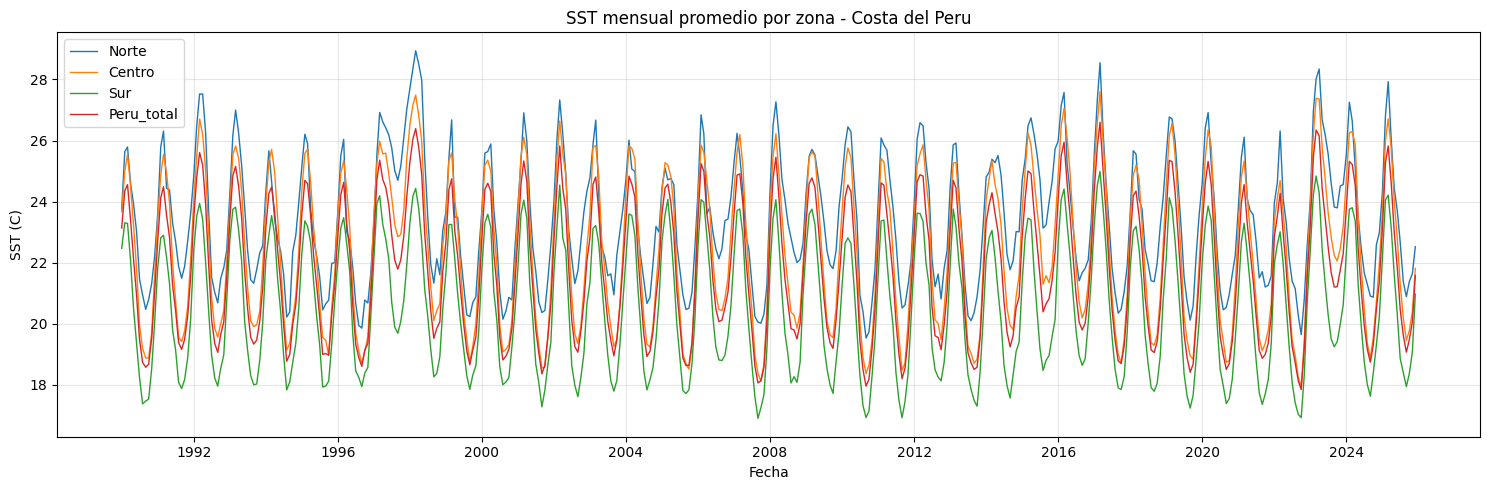

In [ ]:
# Serie mensual por zona
sst_mensual_zonas = (
    df_sst_zonas
    .set_index('fecha')
    .groupby('zona')['sst_promedio']
    .resample('MS')
    .mean()
    .reset_index()
)

plt.figure(figsize=(15, 5))
for zona in ['Norte', 'Centro', 'Sur', 'Peru_total']:
    sub = sst_mensual_zonas[sst_mensual_zonas['zona'] == zona]
    plt.plot(sub['fecha'], sub['sst_promedio'], label=zona, linewidth=1)

plt.title('SST mensual promedio por zona - Costa del Peru')
plt.xlabel('Fecha')
plt.ylabel('SST (C)')
plt.legend()
plt.tight_layout()
plt.show()

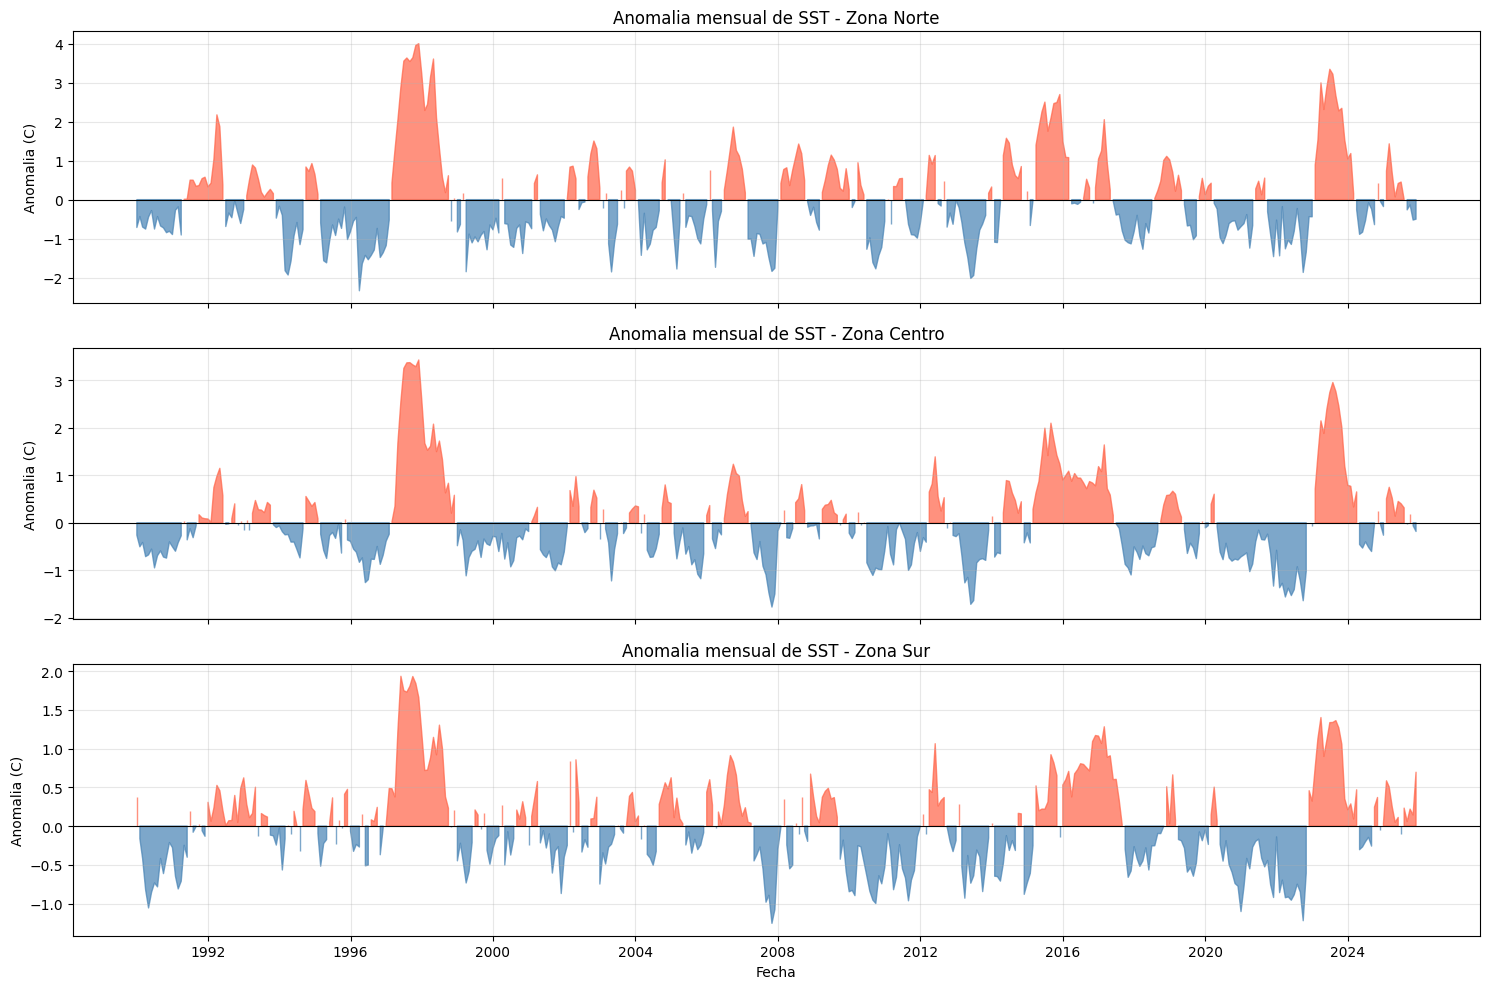

In [ ]:
# Anomalias mensuales por zona
sst_mensual_zonas['mes'] = sst_mensual_zonas['fecha'].dt.month
clim_mes_zona = (
    sst_mensual_zonas
    .groupby(['zona', 'mes'])['sst_promedio']
    .mean()
    .rename('climatologia_mes')
    .reset_index()
)
sst_mensual_zonas = sst_mensual_zonas.merge(clim_mes_zona, on=['zona', 'mes'], how='left')
sst_mensual_zonas['anomalia_mensual'] = sst_mensual_zonas['sst_promedio'] - sst_mensual_zonas['climatologia_mes']

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for ax, zona in zip(axes, ['Norte', 'Centro', 'Sur']):
    sub = sst_mensual_zonas[sst_mensual_zonas['zona'] == zona]
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(sub['fecha'], sub['anomalia_mensual'], 0,
                    where=sub['anomalia_mensual'] >= 0, color='tomato', alpha=0.7)
    ax.fill_between(sub['fecha'], sub['anomalia_mensual'], 0,
                    where=sub['anomalia_mensual'] < 0, color='steelblue', alpha=0.7)
    ax.set_title(f'Anomalia mensual de SST - Zona {zona}')
    ax.set_ylabel('Anomalia (C)')
axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

## 8. Deteccion de olas de calor marinas - metodologia Hobday et al. (2016)

Criterios aplicados:

1. Calculo de climatologia diaria sobre un periodo base.
2. Umbral diario del percentil 90.
3. Dia candidato MHW cuando la SST supera el umbral P90.
4. Evento MHW cuando la condicion dura al menos 5 dias.
5. Union de eventos separados por brechas cortas de hasta 2 dias.

In [ ]:
BASELINE = (1990, 2025)
PERCENTIL = 90
VENTANA_DIAS = 11
SUAVIZADO_DIAS = 31
DURACION_MINIMA = 5
MAX_GAP = 2

print('Parametros:')
print('Baseline:', BASELINE)
print('Percentil:', PERCENTIL)
print('Ventana:', VENTANA_DIAS)
print('Suavizado:', SUAVIZADO_DIAS)
print('Duracion minima:', DURACION_MINIMA)
print('Max gap:', MAX_GAP)

Parametros:
Baseline: (1990, 2025)
Percentil: 90
Ventana: 11
Suavizado: 31
Duracion minima: 5
Max gap: 2


In [ ]:
def doy_sin_bisiesto(fechas):
    fechas = pd.to_datetime(fechas)
    doy = fechas.dt.dayofyear.astype(float)
    es_bisiesto = fechas.dt.is_leap_year
    despues_feb = fechas.dt.month > 2
    es_29feb = (fechas.dt.month == 2) & (fechas.dt.day == 29)
    doy.loc[es_bisiesto & despues_feb] -= 1
    doy.loc[es_29feb] = np.nan
    return doy


def suavizado_circular(valores, ventana=31):
    valores = np.asarray(valores, dtype=float)
    pad = ventana // 2
    extendido = np.r_[valores[-pad:], valores, valores[:pad]]
    suavizado = (
        pd.Series(extendido)
        .rolling(window=ventana, center=True, min_periods=1)
        .mean()
        .iloc[pad:pad + len(valores)]
        .to_numpy()
    )
    return suavizado


def calcular_climatologia_hobday_zona(df_zona, baseline=BASELINE, percentil=PERCENTIL,
                                      ventana_dias=VENTANA_DIAS, suavizado_dias=SUAVIZADO_DIAS):
    df = df_zona.copy().sort_values('fecha')
    df['doy'] = doy_sin_bisiesto(df['fecha'])
    df = df.dropna(subset=['doy']).copy()
    df['doy'] = df['doy'].astype(int)
    df['anio'] = df['fecha'].dt.year

    base = df[(df['anio'] >= baseline[0]) & (df['anio'] <= baseline[1])].copy()
    if base.empty:
        raise ValueError('El periodo baseline no tiene datos para esta zona.')

    mitad = ventana_dias // 2
    registros = []
    for d in range(1, 366):
        distancia = ((base['doy'] - d + 182) % 365) - 182
        muestra = base.loc[distancia.abs() <= mitad, 'sst_promedio'].dropna()
        registros.append({
            'doy': d,
            'climatologia': muestra.mean(),
            'umbral_p90': np.nanpercentile(muestra, percentil),
            'n_datos_base': len(muestra),
        })

    clim = pd.DataFrame(registros)
    clim['climatologia'] = suavizado_circular(clim['climatologia'], ventana=suavizado_dias)
    clim['umbral_p90'] = suavizado_circular(clim['umbral_p90'], ventana=suavizado_dias)
    return clim


def unir_brechas_cortas(condicion, max_gap=2):
    arr = np.asarray(condicion, dtype=bool).copy()
    n = len(arr)
    i = 0
    while i < n:
        if arr[i]:
            i += 1
            continue
        inicio = i
        while i < n and not arr[i]:
            i += 1
        fin = i - 1
        largo = fin - inicio + 1
        hay_antes = inicio > 0 and arr[inicio - 1]
        hay_despues = i < n and arr[i]
        if hay_antes and hay_despues and largo <= max_gap:
            arr[inicio:fin + 1] = True
    return arr


def detectar_eventos_mhw_zona(df_zona, zona, min_duracion=DURACION_MINIMA, max_gap=MAX_GAP):
    df = df_zona.sort_values('fecha').reset_index(drop=True).copy()
    condicion_unida = unir_brechas_cortas(df['sobre_umbral'].fillna(False).values, max_gap=max_gap)
    df['mhw_candidato'] = condicion_unida
    df['mhw'] = False
    df['evento_id_zona'] = np.nan

    eventos = []
    evento_id = 1
    n = len(df)
    i = 0

    while i < n:
        if not condicion_unida[i]:
            i += 1
            continue

        inicio = i
        while i < n and condicion_unida[i]:
            i += 1
        fin = i - 1
        duracion = fin - inicio + 1

        if duracion >= min_duracion:
            idx = np.arange(inicio, fin + 1)
            sub = df.iloc[idx].copy()
            idx_pico = sub['anomalia_climatologica'].idxmax()
            fila_pico = df.loc[idx_pico]

            df.loc[idx, 'mhw'] = True
            df.loc[idx, 'evento_id_zona'] = evento_id

            eventos.append({
                'zona': zona,
                'evento_id_zona': evento_id,
                'fecha_inicio': sub['fecha'].min(),
                'fecha_fin': sub['fecha'].max(),
                'anio_inicio': sub['fecha'].min().year,
                'duracion_dias': duracion,
                'dias_sobre_umbral': int(sub['sobre_umbral'].sum()),
                'fecha_pico': fila_pico['fecha'],
                'sst_pico': fila_pico['sst_promedio'],
                'intensidad_maxima': sub['anomalia_climatologica'].max(),
                'intensidad_media': sub['anomalia_climatologica'].mean(),
                'intensidad_acumulada': sub['anomalia_climatologica'].sum(),
                'exceso_umbral_maximo': sub['exceso_umbral'].max(),
                'exceso_umbral_medio': sub['exceso_umbral'].mean(),
            })
            evento_id += 1

    return df, pd.DataFrame(eventos)

In [ ]:
# Calcular climatologia y detectar eventos para cada zona
mhw_diario_lista = []
eventos_lista = []
clim_lista = []

for zona, sub in tqdm(df_sst_zonas.groupby('zona'), desc='Detectando MHW por zona'):
    clim_z = calcular_climatologia_hobday_zona(sub)
    clim_z['zona'] = zona
    clim_lista.append(clim_z)

    tmp = sub.copy()
    tmp['doy'] = doy_sin_bisiesto(tmp['fecha'])
    tmp = tmp.dropna(subset=['doy']).copy()
    tmp['doy'] = tmp['doy'].astype(int)
    tmp = tmp.merge(clim_z[['doy', 'climatologia', 'umbral_p90']], on='doy', how='left')
    tmp['anomalia_climatologica'] = tmp['sst_promedio'] - tmp['climatologia']
    tmp['exceso_umbral'] = tmp['sst_promedio'] - tmp['umbral_p90']
    tmp['sobre_umbral'] = tmp['sst_promedio'] > tmp['umbral_p90']

    mhw_z, eventos_z = detectar_eventos_mhw_zona(tmp, zona=zona)
    mhw_diario_lista.append(mhw_z)
    eventos_lista.append(eventos_z)

climatologia_zonas = pd.concat(clim_lista, ignore_index=True)
mhw_diario = pd.concat(mhw_diario_lista, ignore_index=True)
eventos_mhw = pd.concat(eventos_lista, ignore_index=True)

# ID global para exportacion
if len(eventos_mhw) > 0:
    eventos_mhw = eventos_mhw.sort_values(['zona', 'fecha_inicio']).reset_index(drop=True)
    eventos_mhw['evento_id_global'] = np.arange(1, len(eventos_mhw) + 1)

print('Eventos detectados por zona:')
print(eventos_mhw.groupby('zona').size().sort_index())
display(eventos_mhw.head())

Detectando MHW por zona:   0%|          | 0/4 [00:00<?, ?it/s]

Eventos detectados por zona:
zona
Centro        35
Norte         35
Peru_total    29
Sur           41
dtype: int64


,zona,evento_id_zona,fecha_inicio,fecha_fin,anio_inicio,duracion_dias,dias_sobre_umbral,fecha_pico,sst_pico,intensidad_maxima,intensidad_media,intensidad_acumulada,exceso_umbral_maximo,exceso_umbral_medio,evento_id_global
0,Centro,1,1992-03-30,1992-04-17,1992,19,19,1992-04-10,26.739109,1.310035,1.130918,21.487448,0.338257,0.143374,1
1,Centro,2,1992-04-28,1992-05-11,1992,14,14,1992-05-08,26.111694,1.833747,1.426022,19.964309,0.674769,0.300538,2
2,Centro,3,1997-05-04,1998-06-15,1997,408,407,1997-12-12,25.583363,3.815134,2.587326,1055.629080,2.784729,1.455970,3
3,Centro,4,1998-07-05,1998-07-13,1998,9,9,1998-07-09,23.152332,1.966913,1.856295,16.706654,0.422705,0.314176,4
4,Centro,5,1998-07-20,1998-08-12,1998,24,24,1998-07-29,22.537674,2.131320,1.759846,42.236314,0.708304,0.375188,5


In [ ]:
# Resumen anual por zona
resumen_anual = (
    mhw_diario
    .groupby(['zona', mhw_diario['fecha'].dt.year])
    .agg(
        sst_media=('sst_promedio', 'mean'),
        sst_max=('sst_promedio', 'max'),
        dias_mhw=('mhw', 'sum'),
        eventos_mhw=('evento_id_zona', lambda x: x.dropna().nunique()),
        intensidad_maxima_anual=('anomalia_climatologica', 'max'),
        intensidad_acumulada_mhw=('anomalia_climatologica', lambda x: x[mhw_diario.loc[x.index, 'mhw']].sum())
    )
    .reset_index()
    .rename(columns={'fecha': 'anio'})
)
resumen_anual['dias_mhw'] = resumen_anual['dias_mhw'].astype(int)
resumen_anual['eventos_mhw'] = resumen_anual['eventos_mhw'].astype(int)

display(resumen_anual.sort_values(['zona', 'dias_mhw'], ascending=[True, False]).groupby('zona').head(5))

,zona,anio,sst_media,sst_max,dias_mhw,eventos_mhw,intensidad_maxima_anual,intensidad_acumulada_mhw
33,Centro,2023,24.299307,27.986414,300,2,3.288743,667.085149
7,Centro,1997,24.425529,26.472960,242,1,3.815134,735.890211
8,Centro,1998,23.767756,28.075274,216,5,2.897082,398.030029
25,Centro,2015,23.457567,27.338739,203,4,2.338874,329.049949
26,Centro,2016,23.310369,27.419121,87,7,1.551193,99.013583
69,Norte,2023,25.578907,28.795151,274,4,3.557955,726.415193
43,Norte,1997,25.733194,27.553471,243,1,4.419114,829.700772
61,Norte,2015,25.042309,27.693949,212,4,3.072371,498.432342
44,Norte,1998,25.024195,29.250811,171,2,4.135103,501.521594
63,Norte,2017,23.488073,29.256552,67,2,2.796405,123.398561


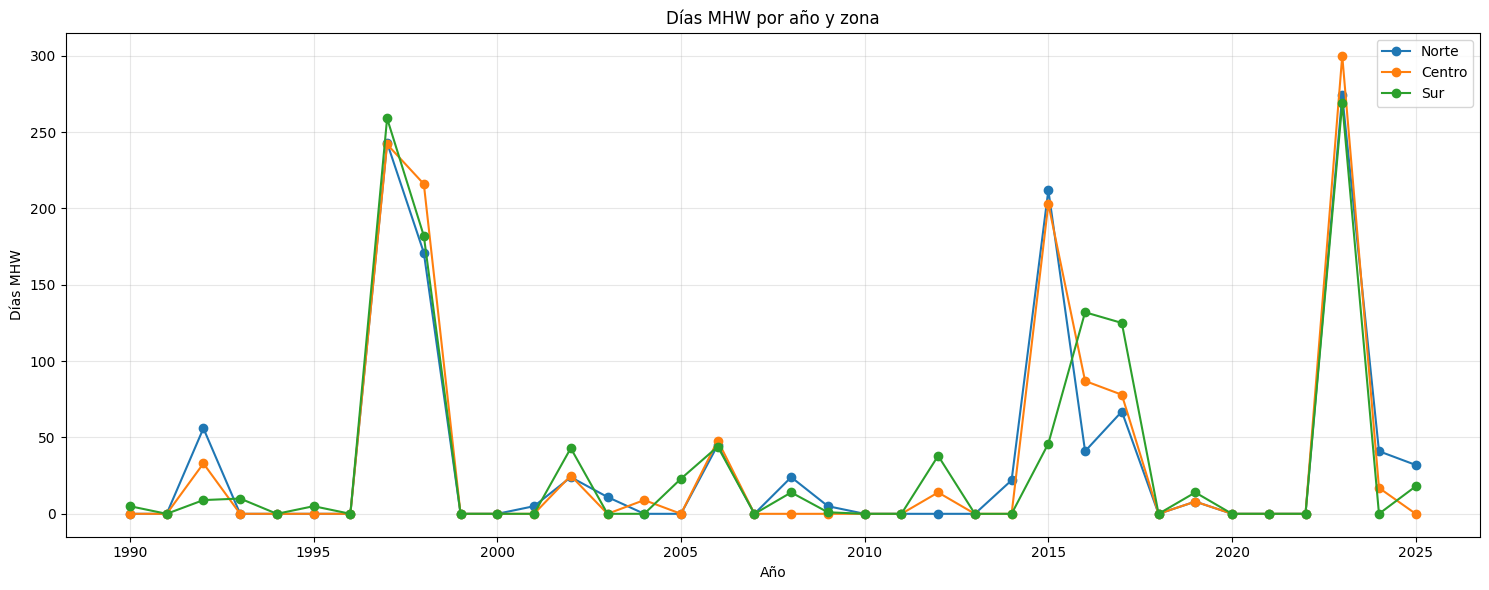

In [ ]:
# Comparacion anual de dias MHW por zona
plt.figure(figsize=(15, 6))
for zona in ['Norte', 'Centro', 'Sur']:
    sub = resumen_anual[resumen_anual['zona'] == zona]
    plt.plot(sub['anio'], sub['dias_mhw'], marker='o', linewidth=1.5, label=zona)
plt.title('Días MHW por año y zona')
plt.xlabel('Año')
plt.ylabel('Días MHW')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Clasificacion de eventos MHW

Se clasifica cada evento segun su intensidad acumulada. Esta clasificacion resume la severidad total del evento porque integra la anomalia de SST durante todos los dias de duracion.

In [ ]:
def clasificar_intensidad_acumulada(valor):
    if valor < 25:
        return 'I - Baja (<25 C dia)'
    elif valor < 100:
        return 'II - Moderada (25-99 C dia)'
    elif valor < 200:
        return 'III - Alta (100-199 C dia)'
    return 'IV - Extrema (>=200 C dia)'


def clasificar_duracion(dias):
    if dias < 30:
        return 'Corta (5-29 dias)'
    elif dias < 100:
        return 'Media (30-99 dias)'
    return 'Larga (>=100 dias)'


eventos_mhw['categoria_intensidad'] = eventos_mhw['intensidad_acumulada'].apply(clasificar_intensidad_acumulada)
eventos_mhw['categoria_duracion'] = eventos_mhw['duracion_dias'].apply(clasificar_duracion)

display(eventos_mhw[[
    'zona', 'evento_id_zona', 'fecha_inicio', 'fecha_fin', 'duracion_dias',
    'intensidad_acumulada', 'categoria_intensidad', 'categoria_duracion'
]].head(20))

,zona,evento_id_zona,fecha_inicio,fecha_fin,duracion_dias,intensidad_acumulada,categoria_intensidad,categoria_duracion
0,Centro,1,1992-03-30,1992-04-17,19,21.487448,I - Baja (<25 C dia),Corta (5-29 dias)
1,Centro,2,1992-04-28,1992-05-11,14,19.964309,I - Baja (<25 C dia),Corta (5-29 dias)
2,Centro,3,1997-05-04,1998-06-15,408,1055.629080,IV - Extrema (>=200 C dia),Larga (>=100 dias)
3,Centro,4,1998-07-05,1998-07-13,9,16.706654,I - Baja (<25 C dia),Corta (5-29 dias)
4,Centro,5,1998-07-20,1998-08-12,24,42.236314,II - Moderada (25-99 C dia),Corta (5-29 dias)
5,Centro,6,1998-08-27,1998-09-04,9,10.260734,I - Baja (<25 C dia),Corta (5-29 dias)
6,Centro,7,1998-10-02,1998-10-09,8,9.087458,I - Baja (<25 C dia),Corta (5-29 dias)
7,Centro,8,2002-03-13,2002-03-26,14,16.608511,I - Baja (<25 C dia),Corta (5-29 dias)
8,Centro,9,2002-05-23,2002-05-27,5,7.649396,I - Baja (<25 C dia),Corta (5-29 dias)
9,Centro,10,2002-12-09,2002-12-14,6,6.923803,I - Baja (<25 C dia),Corta (5-29 dias)


categoria_intensidad,I - Baja (<25 C dia),II - Moderada (25-99 C dia),III - Alta (100-199 C dia),IV - Extrema (>=200 C dia)
zona,,,,
Centro,27,5,0,3
Norte,22,7,3,3
Peru_total,20,5,2,2
Sur,29,8,2,2


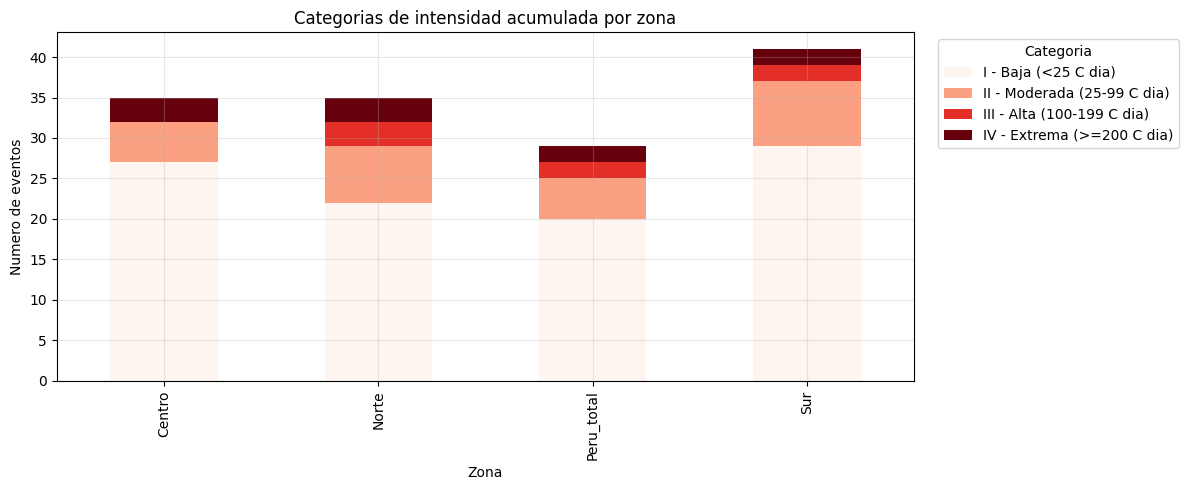

In [ ]:
# Distribucion de categorias por zona
cat_zona = pd.crosstab(eventos_mhw['zona'], eventos_mhw['categoria_intensidad'])
display(cat_zona)

cat_zona.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='Reds')
plt.title('Categorias de intensidad acumulada por zona')
plt.xlabel('Zona')
plt.ylabel('Numero de eventos')
plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Ingenieria de variables para predecir SST

El modelo no predice directamente si ocurre una ola de calor marina. El modelo predice la **temperatura superficial del mar (`sst_promedio`)**.

Luego, con la SST predicha, se aplica la metodologia de Hobday:

1. `anomalia_predicha = sst_predicha - climatologia`
2. `sobre_umbral_predicho = sst_predicha > umbral_p90`
3. Se identifican secuencias de al menos 5 dias sobre el umbral.
4. Se calculan eventos MHW predichos y se comparan con los eventos observados.

Para evitar fuga de informacion, las variables predictoras usan informacion previa: rezagos, medias moviles previas y variables temporales conocidas. Si ICEN esta disponible, se usa como `icen_lag1`, es decir, el ICEN del mes anterior.

In [ ]:
# Construir base diaria para ML
ml = mhw_diario.copy().sort_values(['zona', 'fecha']).reset_index(drop=True)
ml['anio'] = ml['fecha'].dt.year
ml['mes'] = ml['fecha'].dt.month
ml['doy_calendario'] = ml['fecha'].dt.dayofyear
ml['doy_sin'] = np.sin(2 * np.pi * ml['doy'] / 365)
ml['doy_cos'] = np.cos(2 * np.pi * ml['doy'] / 365)

# Integrar ICEN mensual rezagado si existe.
# Cada dia recibe el ICEN del mes anterior (icen_lag1), no el ICEN del mismo mes.
if icen is not None:
    ml['fecha_mes'] = ml['fecha'].dt.to_period('M').dt.to_timestamp()
    ml = ml.merge(icen[['fecha_mes', 'icen_lag1']], on='fecha_mes', how='left')
    ml = ml.drop(columns=['fecha_mes'])
else:
    ml['icen_lag1'] = np.nan

# Integrar viento diario si existe
if df_viento is not None:
    ml = ml.merge(df_viento, on='fecha', how='left')
else:
    ml['u10'] = np.nan
    ml['v10'] = np.nan
    ml['velocidad_viento'] = np.nan

# Variables rezagadas por zona: informacion anterior al dia que se predice
for lag in [1, 3, 7, 14, 30]:
    ml[f'sst_lag{lag}'] = ml.groupby('zona')['sst_promedio'].shift(lag)
    ml[f'anom_lag{lag}'] = ml.groupby('zona')['anomalia_climatologica'].shift(lag)
    ml[f'exceso_lag{lag}'] = ml.groupby('zona')['exceso_umbral'].shift(lag)

# Medias moviles previas. shift(1) evita incluir el dia objetivo.
ml['sst_ma7_prev'] = ml.groupby('zona')['sst_promedio'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
ml['sst_ma30_prev'] = ml.groupby('zona')['sst_promedio'].transform(lambda s: s.shift(1).rolling(30, min_periods=10).mean())
ml['anom_ma7_prev'] = ml.groupby('zona')['anomalia_climatologica'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
ml['exceso_ma7_prev'] = ml.groupby('zona')['exceso_umbral'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())

# Rezagos de viento si ERA5 esta disponible
for col in ['u10', 'v10', 'velocidad_viento']:
    if col in ml.columns:
        ml[f'{col}_lag1'] = ml.groupby('zona')[col].shift(1)
        ml[f'{col}_lag7'] = ml.groupby('zona')[col].shift(7)

FEATURES_CANDIDATAS = [
    'mes', 'doy_sin', 'doy_cos', 'climatologia', 'umbral_p90',
    'sst_lag1', 'sst_lag3', 'sst_lag7', 'sst_lag14', 'sst_lag30',
    'anom_lag1', 'anom_lag3', 'anom_lag7', 'anom_lag14', 'anom_lag30',
    'exceso_lag1', 'exceso_lag3', 'exceso_lag7', 'exceso_lag14', 'exceso_lag30',
    'sst_ma7_prev', 'sst_ma30_prev', 'anom_ma7_prev', 'exceso_ma7_prev',
    'icen_lag1', 'u10_lag1', 'u10_lag7', 'v10_lag1', 'v10_lag7',
    'velocidad_viento_lag1', 'velocidad_viento_lag7'
]

# Se conservan variables con suficiente disponibilidad de datos
feature_cols = []
for col in FEATURES_CANDIDATAS:
    if col in ml.columns and ml[col].notna().mean() >= 0.70:
        feature_cols.append(col)

TARGET_SST = 'sst_promedio'

columnas_base = [
    'fecha', 'zona', 'sst_promedio', 'climatologia', 'umbral_p90',
    'anomalia_climatologica', 'exceso_umbral', 'sobre_umbral', 'mhw'
]

# Evitar columnas duplicadas: algunas variables, como climatologia y umbral_p90,
# estan en columnas_base y tambien pueden usarse como features del modelo.
columnas_modelo = columnas_base + [c for c in feature_cols if c not in columnas_base]

df_ml = ml[columnas_modelo].dropna().copy()
df_ml['mhw'] = df_ml['mhw'].astype(int)

# Verificacion de seguridad: no deben quedar columnas duplicadas.
assert not df_ml.columns.duplicated().any(), 'Hay columnas duplicadas en df_ml'

print('Variable objetivo:', TARGET_SST)
print('Features usadas:', feature_cols)
print('Registros ML:', len(df_ml))
print('Registros por zona:')
print(df_ml['zona'].value_counts().sort_index())
display(df_ml.head())

Variable objetivo: sst_promedio
Features usadas: ['mes', 'doy_sin', 'doy_cos', 'climatologia', 'umbral_p90', 'sst_lag1', 'sst_lag3', 'sst_lag7', 'sst_lag14', 'sst_lag30', 'anom_lag1', 'anom_lag3', 'anom_lag7', 'anom_lag14', 'anom_lag30', 'exceso_lag1', 'exceso_lag3', 'exceso_lag7', 'exceso_lag14', 'exceso_lag30', 'sst_ma7_prev', 'sst_ma30_prev', 'anom_ma7_prev', 'exceso_ma7_prev', 'icen_lag1', 'u10_lag1', 'u10_lag7', 'v10_lag1', 'v10_lag7', 'velocidad_viento_lag1', 'velocidad_viento_lag7']
Registros ML: 52436
Registros por zona:
zona
Centro        13109
Norte         13109
Peru_total    13109
Sur           13109
Name: count, dtype: int64


,fecha,zona,sst_promedio,climatologia,umbral_p90,anomalia_climatologica,exceso_umbral,sobre_umbral,mhw,mes,doy_sin,doy_cos,sst_lag1,sst_lag3,sst_lag7,sst_lag14,sst_lag30,anom_lag1,anom_lag3,anom_lag7,anom_lag14,anom_lag30,exceso_lag1,exceso_lag3,exceso_lag7,exceso_lag14,exceso_lag30,sst_ma7_prev,sst_ma30_prev,anom_ma7_prev,exceso_ma7_prev,icen_lag1,u10_lag1,u10_lag7,v10_lag1,v10_lag7,velocidad_viento_lag1,velocidad_viento_lag7
31,1990-02-01,Centro,24.531191,24.834468,25.686314,-0.303277,-1.155123,False,0,2,0.523416,0.852078,24.515535,24.422855,24.099205,23.525196,23.048344,-0.264195,-0.246116,-0.346823,-0.521209,-0.008707,-1.118536,-1.103509,-1.190687,-1.332060,-0.837545,24.392914,23.694624,-0.220246,-1.072691,-0.23,-2.947951,-1.927103,2.361815,2.697402,3.777379,3.315073
32,1990-02-02,Centro,24.640671,24.888517,25.738962,-0.247847,-1.098291,False,0,2,0.538005,0.842942,24.531191,24.497543,24.373604,23.542217,23.098583,-0.303277,-0.226954,-0.128317,-0.562757,-0.021291,-1.155123,-1.083918,-0.976144,-1.379580,-0.840735,24.454626,23.744052,-0.214025,-1.067611,-0.23,-2.490181,-1.505593,2.443375,2.202419,3.488708,2.667857
33,1990-02-03,Centro,24.727659,24.941708,25.792412,-0.214049,-1.064753,False,0,2,0.552435,0.833556,24.640671,24.515535,24.418898,23.612833,23.090693,-0.247847,-0.264195,-0.138749,-0.550161,-0.091848,-1.098291,-1.118536,-0.990499,-1.371737,-0.902235,24.492779,23.795455,-0.231101,-1.085060,-0.23,-2.230554,-2.265854,2.501443,2.694037,3.351505,3.520218
34,1990-02-04,Centro,24.876652,24.994028,25.847984,-0.117376,-0.971332,False,0,2,0.566702,0.823923,24.727659,24.531191,24.422756,23.672348,23.121454,-0.214049,-0.303277,-0.190567,-0.548098,-0.123664,-1.064753,-1.155123,-1.045546,-1.375484,-0.925828,24.536887,23.850021,-0.241858,-1.095668,-0.23,-2.415950,-2.563810,2.293493,3.137378,3.331205,4.051698
35,1990-02-05,Centro,24.873394,25.045349,25.904175,-0.171955,-1.030781,False,0,2,0.580800,0.814046,24.876652,24.640671,24.422855,23.797773,23.175056,-0.117376,-0.247847,-0.246116,-0.479599,-0.132564,-0.971332,-1.098291,-1.103509,-1.312225,-0.928882,24.601730,23.908527,-0.231402,-1.085066,-0.23,-2.642171,-2.400286,2.709621,3.221236,3.784589,4.017180


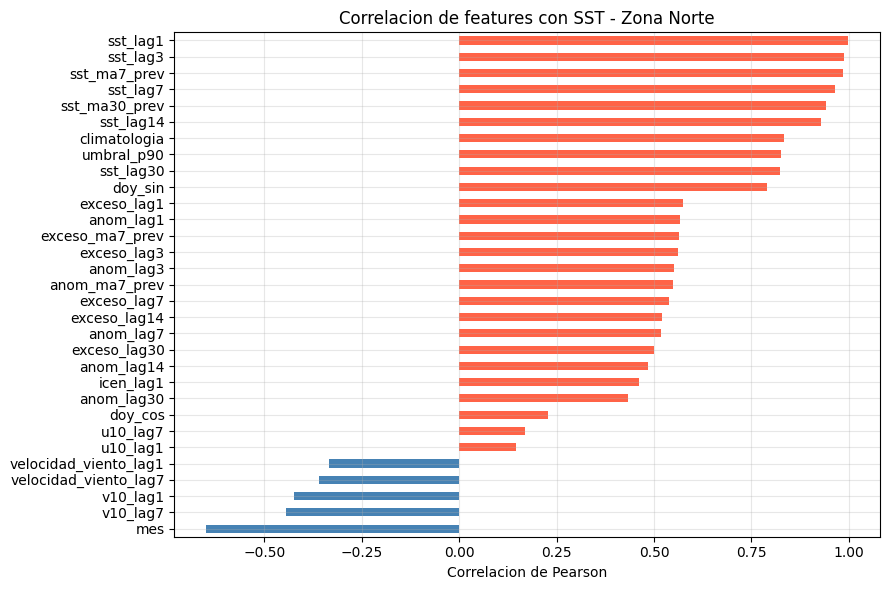

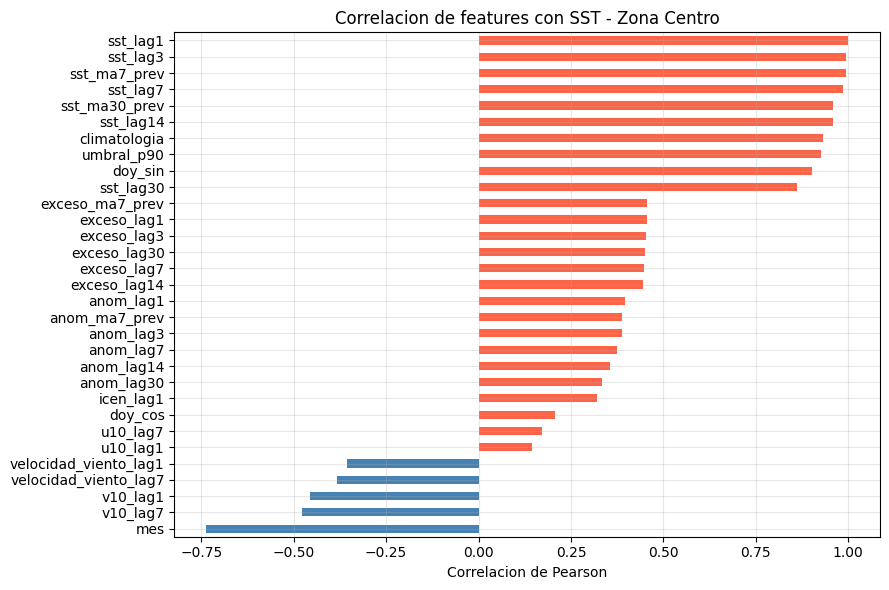

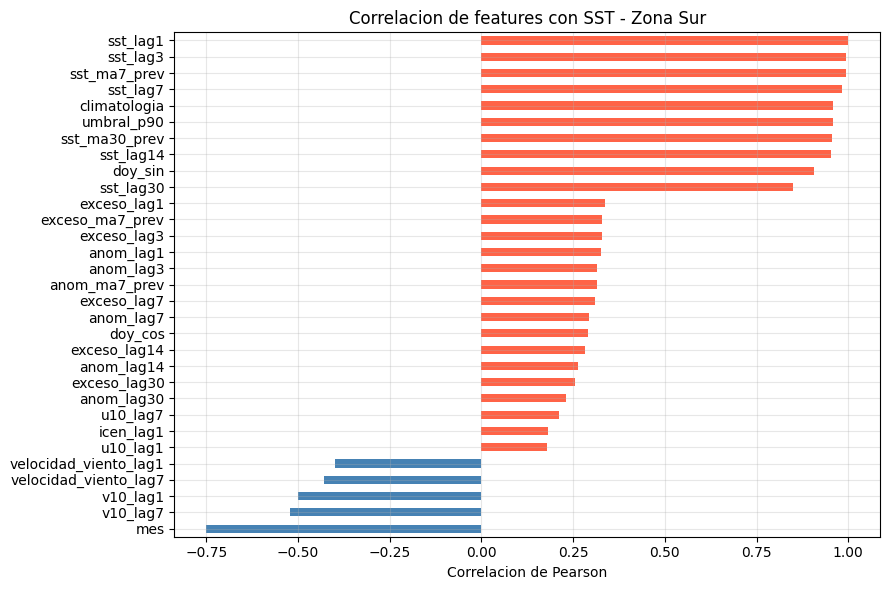

In [ ]:
# Correlacion exploratoria de features con SST por zona
for zona in ['Norte', 'Centro', 'Sur']:
    sub = df_ml[df_ml['zona'] == zona]
    corr = sub[feature_cols + [TARGET_SST]].corr()[TARGET_SST].drop(TARGET_SST).sort_values()
    plt.figure(figsize=(9, 6))
    corr.plot(kind='barh', color=['steelblue' if v < 0 else 'tomato' for v in corr])
    plt.title(f'Correlacion de features con SST - Zona {zona}')
    plt.xlabel('Correlacion de Pearson')
    plt.tight_layout()
    plt.show()

## 11. Random Forest Regressor con tres configuraciones

Se entrenan tres configuraciones para predecir SST en cada zona. La division 70/30 es cronologica:

- **Entrenamiento:** primer 70% de registros.
- **Prueba:** ultimo 30% de registros.

Metricas principales del modelo de temperatura:

| Metrica | Interpretacion |
|---|---|
| MAE | Error absoluto promedio en grados C |
| RMSE | Error cuadratico medio, penaliza mas errores grandes |
| R2 | Proporcion de variabilidad de SST explicada por el modelo |

Despues se evalua la deteccion MHW derivada de la SST predicha usando precision, recall y F1 de la clase MHW.

In [ ]:
RF_CONFIGS = {
    'RF_1_conservador': {
        'n_estimators': 200,
        'max_depth': 8,
        'min_samples_leaf': 8,
        'min_samples_split': 10,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1,
    },
    'RF_2_intermedio': {
        'n_estimators': 400,
        'max_depth': 14,
        'min_samples_leaf': 4,
        'min_samples_split': 8,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1,
    },
    'RF_3_profundo': {
        'n_estimators': 600,
        'max_depth': None,
        'min_samples_leaf': 2,
        'min_samples_split': 4,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1,
    },
}


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def detectar_mhw_desde_sst_predicha(df_test, sst_predicha, zona, modelo_nombre):
    """Aplica Hobday sobre SST predicha dentro del periodo de prueba."""
    pred = df_test[['fecha', 'zona', 'climatologia', 'umbral_p90']].copy()
    pred['sst_promedio'] = sst_predicha
    pred['anomalia_climatologica'] = pred['sst_promedio'] - pred['climatologia']
    pred['exceso_umbral'] = pred['sst_promedio'] - pred['umbral_p90']
    pred['sobre_umbral'] = pred['sst_promedio'] > pred['umbral_p90']

    diario_pred, eventos_pred = detectar_eventos_mhw_zona(
        pred, zona=f'{zona}_{modelo_nombre}',
        min_duracion=DURACION_MINIMA,
        max_gap=MAX_GAP
    )
    diario_pred = diario_pred.rename(columns={
        'sst_promedio': 'sst_predicha',
        'anomalia_climatologica': 'anomalia_predicha',
        'exceso_umbral': 'exceso_umbral_predicho',
        'sobre_umbral': 'sobre_umbral_predicho',
        'mhw': 'mhw_predicho'
    })
    diario_pred['zona_original'] = zona
    diario_pred['modelo'] = modelo_nombre

    if len(eventos_pred) > 0:
        eventos_pred['zona_original'] = zona
        eventos_pred['modelo'] = modelo_nombre

    return diario_pred, eventos_pred


def evaluar_regresores_por_zona(df, zona, feature_cols, target='sst_promedio', train_size=0.70):
    data = df[df['zona'] == zona].sort_values('fecha').reset_index(drop=True).copy()
    split_idx = int(len(data) * train_size)

    train = data.iloc[:split_idx].copy()
    test = data.iloc[split_idx:].copy()

    X_train = train[feature_cols]
    y_train = train[target]
    X_test = test[feature_cols]
    y_test = test[target]

    resultados = []
    modelos = {}
    predicciones = test[[
        'fecha', 'zona', 'sst_promedio', 'climatologia', 'umbral_p90',
        'anomalia_climatologica', 'exceso_umbral', 'mhw'
    ]].copy().rename(columns={'sst_promedio': 'sst_observada', 'mhw': 'mhw_observada'})

    diarios_predichos = []
    eventos_predichos = []

    for nombre, params in RF_CONFIGS.items():
        modelo = RandomForestRegressor(**params)
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        diario_pred, eventos_pred = detectar_mhw_desde_sst_predicha(test, y_pred, zona, nombre)

        # Unir mhw_predicho por fecha para comparacion binaria
        comp = predicciones[['fecha', 'mhw_observada']].merge(
            diario_pred[['fecha', 'mhw_predicho', 'sst_predicha']], on='fecha', how='left'
        )
        comp['mhw_predicho'] = comp['mhw_predicho'].fillna(False).astype(int)
        comp['mhw_observada'] = comp['mhw_observada'].astype(int)

        resultados.append({
            'zona': zona,
            'modelo': nombre,
            'n_train': len(train),
            'n_test': len(test),
            'inicio_train': train['fecha'].min(),
            'fin_train': train['fecha'].max(),
            'inicio_test': test['fecha'].min(),
            'fin_test': test['fecha'].max(),
            'mae_sst': mean_absolute_error(y_test, y_pred),
            'rmse_sst': rmse_score(y_test, y_pred),
            'r2_sst': r2_score(y_test, y_pred),
            'bias_sst': np.mean(y_pred - y_test),
            'dias_mhw_observados_test': int(comp['mhw_observada'].sum()),
            'dias_mhw_predichos_test': int(comp['mhw_predicho'].sum()),
            'eventos_mhw_predichos_test': int(len(eventos_pred)),
            'precision_mhw_derivada': precision_score(comp['mhw_observada'], comp['mhw_predicho'], zero_division=0),
            'recall_mhw_derivada': recall_score(comp['mhw_observada'], comp['mhw_predicho'], zero_division=0),
            'f1_mhw_derivada': f1_score(comp['mhw_observada'], comp['mhw_predicho'], zero_division=0),
            'accuracy_mhw_derivada': accuracy_score(comp['mhw_observada'], comp['mhw_predicho']),
        })

        modelos[nombre] = modelo
        predicciones[f'sst_pred_{nombre}'] = y_pred
        predicciones[f'mhw_pred_{nombre}'] = comp['mhw_predicho'].values
        diarios_predichos.append(diario_pred)
        eventos_predichos.append(eventos_pred)

    diarios_predichos = pd.concat(diarios_predichos, ignore_index=True)
    eventos_predichos = pd.concat([e for e in eventos_predichos if len(e) > 0], ignore_index=True) if any(len(e) > 0 for e in eventos_predichos) else pd.DataFrame()

    return pd.DataFrame(resultados), modelos, predicciones, diarios_predichos, eventos_predichos, (X_train, X_test, y_train, y_test)

In [ ]:
zonas_modelo = ['Norte', 'Centro', 'Sur']
resultados_lista = []
modelos_por_zona = {}
predicciones_lista = []
diarios_predichos_lista = []
eventos_predichos_lista = []
splits_por_zona = {}

for zona in zonas_modelo:
    res_z, modelos_z, pred_z, diarios_z, eventos_z, split_z = evaluar_regresores_por_zona(
        df_ml, zona, feature_cols, target=TARGET_SST, train_size=0.70
    )
    resultados_lista.append(res_z)
    modelos_por_zona[zona] = modelos_z
    predicciones_lista.append(pred_z)
    diarios_predichos_lista.append(diarios_z)
    if len(eventos_z) > 0:
        eventos_predichos_lista.append(eventos_z)
    splits_por_zona[zona] = split_z

tabla_modelos = pd.concat(resultados_lista, ignore_index=True)
predicciones_test = pd.concat(predicciones_lista, ignore_index=True)
diario_predicho_modelos = pd.concat(diarios_predichos_lista, ignore_index=True)
eventos_predichos_modelos = pd.concat(eventos_predichos_lista, ignore_index=True) if eventos_predichos_lista else pd.DataFrame()

cols_metricas = [
    'zona', 'modelo', 'n_train', 'n_test', 'inicio_train', 'fin_train', 'inicio_test', 'fin_test',
    'mae_sst', 'rmse_sst', 'r2_sst', 'bias_sst',
    'dias_mhw_observados_test', 'dias_mhw_predichos_test', 'eventos_mhw_predichos_test',
    'precision_mhw_derivada', 'recall_mhw_derivada', 'f1_mhw_derivada', 'accuracy_mhw_derivada'
]

display(tabla_modelos[cols_metricas].round(4))

,zona,modelo,n_train,n_test,inicio_train,fin_train,inicio_test,fin_test,mae_sst,rmse_sst,r2_sst,bias_sst,dias_mhw_observados_test,dias_mhw_predichos_test,eventos_mhw_predichos_test,precision_mhw_derivada,recall_mhw_derivada,f1_mhw_derivada,accuracy_mhw_derivada
0,Norte,RF_1_conservador,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.1481,0.1946,0.9923,-0.0068,675,635,12,0.9543,0.8978,0.9252,0.9751
1,Norte,RF_2_intermedio,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.1232,0.1634,0.9946,-0.0055,675,649,14,0.9661,0.9289,0.9471,0.9822
2,Norte,RF_3_profundo,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.1222,0.1615,0.9947,-0.0073,675,637,14,0.9702,0.9156,0.9421,0.9807
3,Centro,RF_1_conservador,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.1037,0.1458,0.9968,-0.0078,689,619,15,0.9661,0.8679,0.9144,0.9715
4,Centro,RF_2_intermedio,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.0874,0.1280,0.9975,-0.0062,689,641,15,0.9704,0.9028,0.9353,0.9781
5,Centro,RF_3_profundo,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.0864,0.1254,0.9976,-0.0071,689,638,15,0.9718,0.8999,0.9344,0.9779
6,Sur,RF_1_conservador,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.0898,0.1305,0.9966,-0.0109,604,543,17,0.9558,0.8593,0.9050,0.9723
7,Sur,RF_2_intermedio,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.0738,0.1082,0.9977,-0.0083,604,577,17,0.9515,0.9089,0.9297,0.9789
8,Sur,RF_3_profundo,9176,3933,1990-02-01,2015-03-23,2015-03-24,2025-12-31,0.0724,0.1054,0.9978,-0.0090,604,580,16,0.9552,0.9172,0.9358,0.9807


In [ ]:
# Seleccion del mejor modelo por zona segun RMSE de SST
mejores_por_zona = (
    tabla_modelos
    .sort_values(['zona', 'rmse_sst', 'mae_sst', 'r2_sst'], ascending=[True, True, True, False])
    .groupby('zona')
    .head(1)
    .reset_index(drop=True)
)

print('Mejor configuracion por zona segun RMSE de SST:')
display(mejores_por_zona[[
    'zona', 'modelo', 'mae_sst', 'rmse_sst', 'r2_sst',
    'precision_mhw_derivada', 'recall_mhw_derivada', 'f1_mhw_derivada'
]].round(4))

mejor_global = tabla_modelos.sort_values(['rmse_sst', 'mae_sst'], ascending=True).iloc[0]
print('\nMejor resultado global segun RMSE:')
print(mejor_global[['zona', 'modelo', 'mae_sst', 'rmse_sst', 'r2_sst', 'f1_mhw_derivada']])

Mejor configuracion por zona segun RMSE de SST:


,zona,modelo,mae_sst,rmse_sst,r2_sst,precision_mhw_derivada,recall_mhw_derivada,f1_mhw_derivada
0,Centro,RF_3_profundo,0.0864,0.1254,0.9976,0.9718,0.8999,0.9344
1,Norte,RF_3_profundo,0.1222,0.1615,0.9947,0.9702,0.9156,0.9421
2,Sur,RF_3_profundo,0.0724,0.1054,0.9978,0.9552,0.9172,0.9358



Mejor resultado global segun RMSE:
zona                         Sur
modelo             RF_3_profundo
mae_sst                 0.072419
rmse_sst                0.105449
r2_sst                   0.99777
f1_mhw_derivada         0.935811
Name: 8, dtype: object


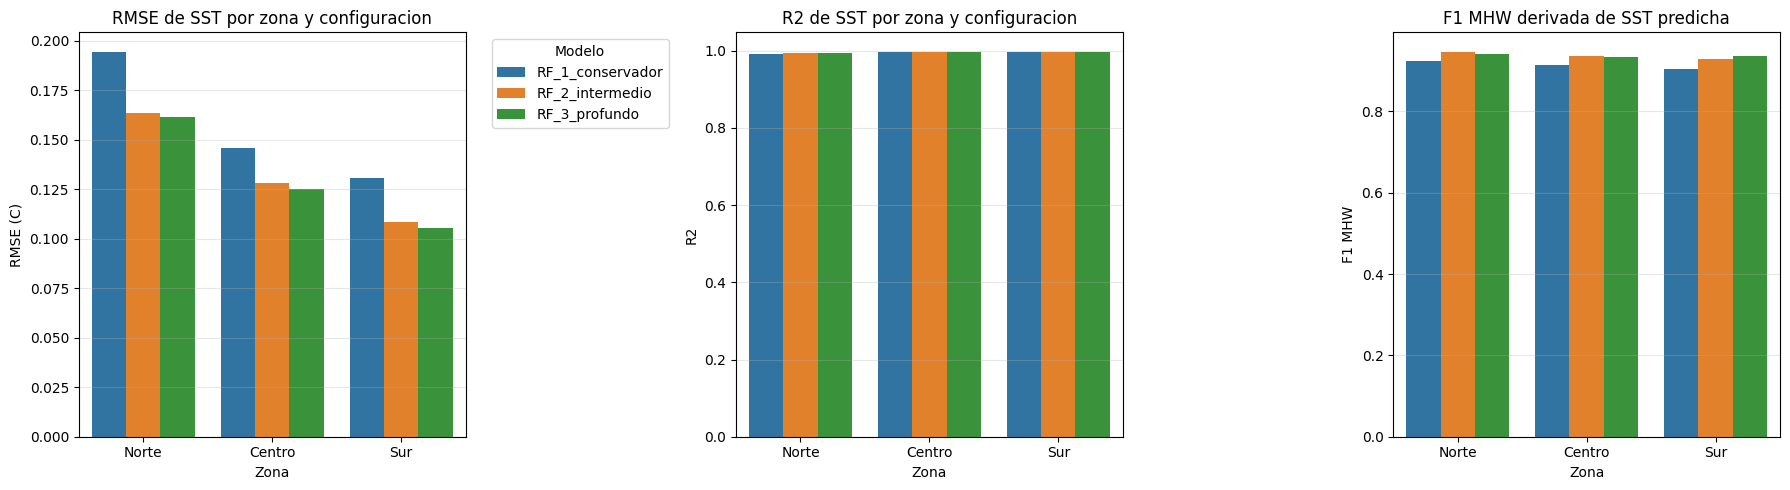

In [ ]:
# Graficos comparativos de las tres configuraciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=tabla_modelos, x='zona', y='rmse_sst', hue='modelo', ax=axes[0])
axes[0].set_title('RMSE de SST por zona y configuracion')
axes[0].set_ylabel('RMSE (C)')
axes[0].set_xlabel('Zona')

sns.barplot(data=tabla_modelos, x='zona', y='r2_sst', hue='modelo', ax=axes[1])
axes[1].set_title('R2 de SST por zona y configuracion')
axes[1].set_ylabel('R2')
axes[1].set_xlabel('Zona')
axes[1].legend_.remove()

sns.barplot(data=tabla_modelos, x='zona', y='f1_mhw_derivada', hue='modelo', ax=axes[2])
axes[2].set_title('F1 MHW derivada de SST predicha')
axes[2].set_ylabel('F1 MHW')
axes[2].set_xlabel('Zona')
axes[2].legend_.remove()

axes[0].legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

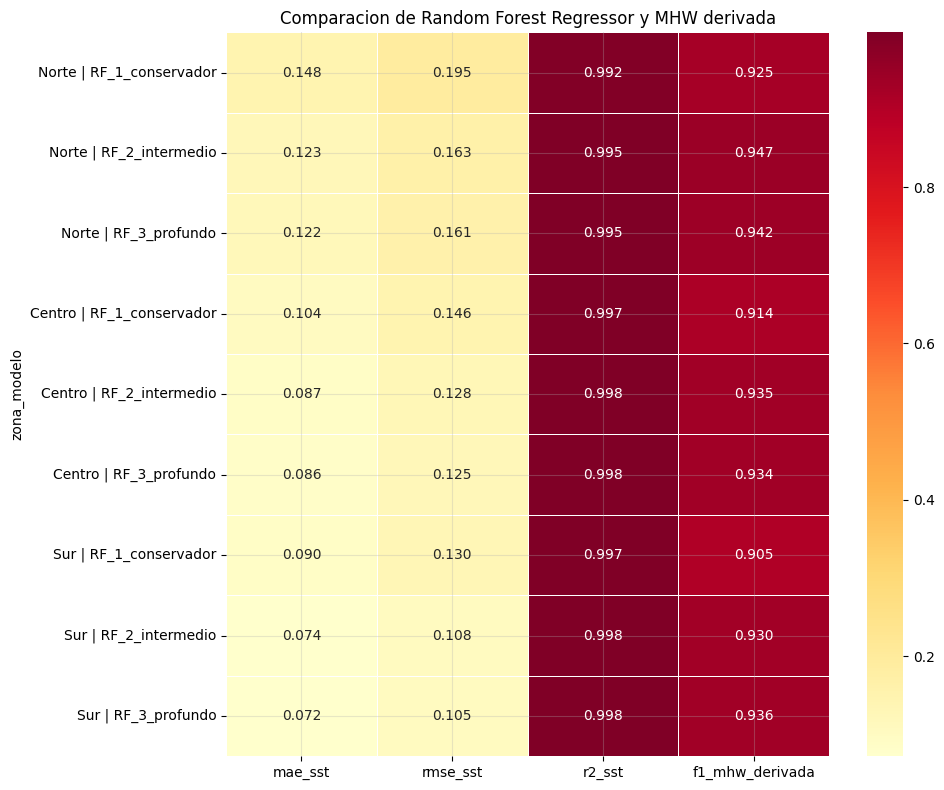

In [ ]:
# Heatmap de metricas principales
metricas_heat = tabla_modelos.copy()
metricas_heat['zona_modelo'] = metricas_heat['zona'] + ' | ' + metricas_heat['modelo']
metricas_heat = metricas_heat.set_index('zona_modelo')[['mae_sst', 'rmse_sst', 'r2_sst', 'f1_mhw_derivada']]

plt.figure(figsize=(10, 8))
sns.heatmap(metricas_heat, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Comparacion de Random Forest Regressor y MHW derivada')
plt.tight_layout()
plt.show()

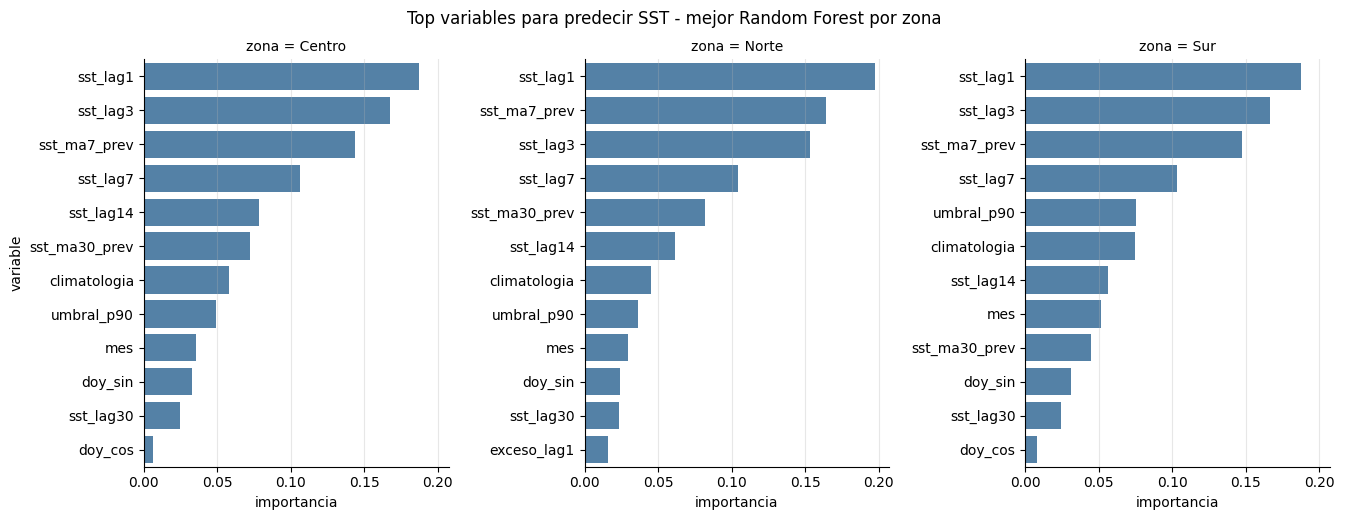

,zona,modelo,variable,importancia
0,Centro,RF_3_profundo,sst_lag1,0.187300
1,Centro,RF_3_profundo,sst_lag3,0.167223
2,Centro,RF_3_profundo,sst_ma7_prev,0.143592
3,Centro,RF_3_profundo,sst_lag7,0.106168
4,Centro,RF_3_profundo,sst_lag14,0.078174
5,Centro,RF_3_profundo,sst_ma30_prev,0.071975
6,Centro,RF_3_profundo,climatologia,0.057675
7,Centro,RF_3_profundo,umbral_p90,0.048852
8,Centro,RF_3_profundo,mes,0.035606
9,Centro,RF_3_profundo,doy_sin,0.033099


In [ ]:
# Importancia de variables para el mejor modelo de cada zona
importancias = []
for _, row in mejores_por_zona.iterrows():
    zona = row['zona']
    modelo_nombre = row['modelo']
    modelo = modelos_por_zona[zona][modelo_nombre]
    imp = pd.DataFrame({
        'zona': zona,
        'modelo': modelo_nombre,
        'variable': feature_cols,
        'importancia': modelo.feature_importances_,
    }).sort_values('importancia', ascending=False)
    importancias.append(imp)

importancias_mejores = pd.concat(importancias, ignore_index=True)

g = sns.catplot(
    data=importancias_mejores.groupby('zona').head(12),
    x='importancia', y='variable', col='zona', kind='bar',
    sharey=False, height=5, aspect=0.9, color='steelblue'
)
g.fig.suptitle('Top variables para predecir SST - mejor Random Forest por zona', y=1.03)
plt.show()

display(importancias_mejores.groupby('zona').head(10))

## 12. Aplicacion de Hobday sobre la SST predicha

En esta seccion se toma el mejor modelo de SST por zona y se conserva una sola serie predicha por zona. Sobre esa serie se aplica la misma logica de deteccion MHW usada para los datos observados.

Esto permite responder la pregunta del proyecto de manera metodologicamente correcta:

**Primero se predice SST. Luego se detectan olas de calor marinas a partir de la SST predicha.**

In [ ]:
predicciones_mejor_modelo = []
eventos_predichos_mejor = []
diario_predicho_mejor = []

for _, row in mejores_por_zona.iterrows():
    zona = row['zona']
    modelo_nombre = row['modelo']

    pred_z = predicciones_test[predicciones_test['zona'] == zona].copy()
    pred_z['modelo_seleccionado'] = modelo_nombre
    pred_z['sst_predicha'] = pred_z[f'sst_pred_{modelo_nombre}']
    pred_z['mhw_predicha'] = pred_z[f'mhw_pred_{modelo_nombre}']
    pred_z['error_sst'] = pred_z['sst_predicha'] - pred_z['sst_observada']
    pred_z['anomalia_predicha'] = pred_z['sst_predicha'] - pred_z['climatologia']
    pred_z['exceso_umbral_predicho'] = pred_z['sst_predicha'] - pred_z['umbral_p90']
    predicciones_mejor_modelo.append(pred_z[[
        'fecha', 'zona', 'modelo_seleccionado', 'sst_observada', 'sst_predicha', 'error_sst',
        'climatologia', 'umbral_p90', 'mhw_observada', 'mhw_predicha',
        'anomalia_climatologica', 'anomalia_predicha', 'exceso_umbral', 'exceso_umbral_predicho'
    ]])

    diario_z = diario_predicho_modelos[
        (diario_predicho_modelos['zona_original'] == zona) &
        (diario_predicho_modelos['modelo'] == modelo_nombre)
    ].copy()
    diario_predicho_mejor.append(diario_z)

    if len(eventos_predichos_modelos) > 0:
        eventos_z = eventos_predichos_modelos[
            (eventos_predichos_modelos['zona_original'] == zona) &
            (eventos_predichos_modelos['modelo'] == modelo_nombre)
        ].copy()
        if len(eventos_z) > 0:
            eventos_predichos_mejor.append(eventos_z)

predicciones_mejor_modelo = pd.concat(predicciones_mejor_modelo, ignore_index=True)
diario_predicho_mejor = pd.concat(diario_predicho_mejor, ignore_index=True)
eventos_predichos_mejor = pd.concat(eventos_predichos_mejor, ignore_index=True) if eventos_predichos_mejor else pd.DataFrame()

print('Predicciones del mejor modelo por zona:')
display(predicciones_mejor_modelo.head())

print('\nEventos MHW detectados desde SST predicha por zona:')
if len(eventos_predichos_mejor) > 0:
    display(eventos_predichos_mejor)
else:
    print('No se detectaron eventos MHW predichos en el periodo de prueba con los mejores modelos.')

Predicciones del mejor modelo por zona:


,fecha,zona,modelo_seleccionado,sst_observada,sst_predicha,error_sst,climatologia,umbral_p90,mhw_observada,mhw_predicha,anomalia_climatologica,anomalia_predicha,exceso_umbral,exceso_umbral_predicho
0,2015-03-24,Centro,RF_3_profundo,27.272696,27.149010,-0.123685,25.891783,26.969973,1,1,1.380913,1.257227,0.302723,0.179038
1,2015-03-25,Centro,RF_3_profundo,27.263058,27.115158,-0.147899,25.877190,26.951588,1,1,1.385868,1.237968,0.311469,0.163570
2,2015-03-26,Centro,RF_3_profundo,27.163256,27.124234,-0.039021,25.860925,26.929732,1,1,1.302331,1.263310,0.233523,0.194502
3,2015-03-27,Centro,RF_3_profundo,27.012432,27.072355,0.059923,25.842810,26.906443,1,1,1.169622,1.229545,0.105989,0.165912
4,2015-03-28,Centro,RF_3_profundo,26.908237,26.931183,0.022946,25.822804,26.880525,1,1,1.085434,1.108379,0.027713,0.050658



Eventos MHW detectados desde SST predicha por zona:


,zona,evento_id_zona,fecha_inicio,fecha_fin,anio_inicio,duracion_dias,dias_sobre_umbral,fecha_pico,sst_pico,intensidad_maxima,intensidad_media,intensidad_acumulada,exceso_umbral_maximo,exceso_umbral_medio,zona_original,modelo
0,Centro_RF_3_profundo,1,2015-03-24,2015-03-29,2015,6,6,2015-03-26,27.124234,1.263310,1.196838,7.181026,0.194502,0.131275,Centro,RF_3_profundo
1,Centro_RF_3_profundo,2,2015-06-10,2015-06-15,2015,6,6,2015-06-13,24.084334,1.605356,1.528822,9.172931,0.203226,0.127892,Centro,RF_3_profundo
2,Centro_RF_3_profundo,3,2015-06-23,2015-08-11,2015,50,49,2015-07-13,23.183856,2.169644,1.786630,89.331499,0.595158,0.323953,Centro,RF_3_profundo
3,Centro_RF_3_profundo,4,2015-08-17,2015-11-30,2015,106,105,2015-09-07,21.894955,2.346140,1.680228,178.104175,1.375438,0.602087,Centro,RF_3_profundo
4,Centro_RF_3_profundo,5,2015-12-04,2016-01-16,2015,44,44,2015-12-16,23.292923,1.295013,1.041418,45.822386,0.285747,0.127268,Centro,RF_3_profundo
5,Centro_RF_3_profundo,6,2016-01-31,2016-02-06,2016,7,7,2016-02-01,25.786930,0.952463,0.911077,6.377536,0.100616,0.056270,Centro,RF_3_profundo
6,Centro_RF_3_profundo,7,2016-02-21,2016-03-07,2016,15,15,2016-02-24,27.024510,1.255512,1.169531,17.542968,0.314826,0.186977,Centro,RF_3_profundo
7,Centro_RF_3_profundo,8,2016-03-31,2016-04-09,2016,10,10,2016-04-05,26.958594,1.354682,1.235265,12.352648,0.367602,0.238942,Centro,RF_3_profundo
8,Centro_RF_3_profundo,9,2016-05-12,2016-05-18,2016,7,5,2016-05-14,25.401509,1.399780,1.272593,8.908150,0.181371,0.044328,Centro,RF_3_profundo
9,Centro_RF_3_profundo,10,2017-01-11,2017-02-08,2017,29,28,2017-01-30,26.286674,1.562177,1.192032,34.568936,0.705213,0.358817,Centro,RF_3_profundo


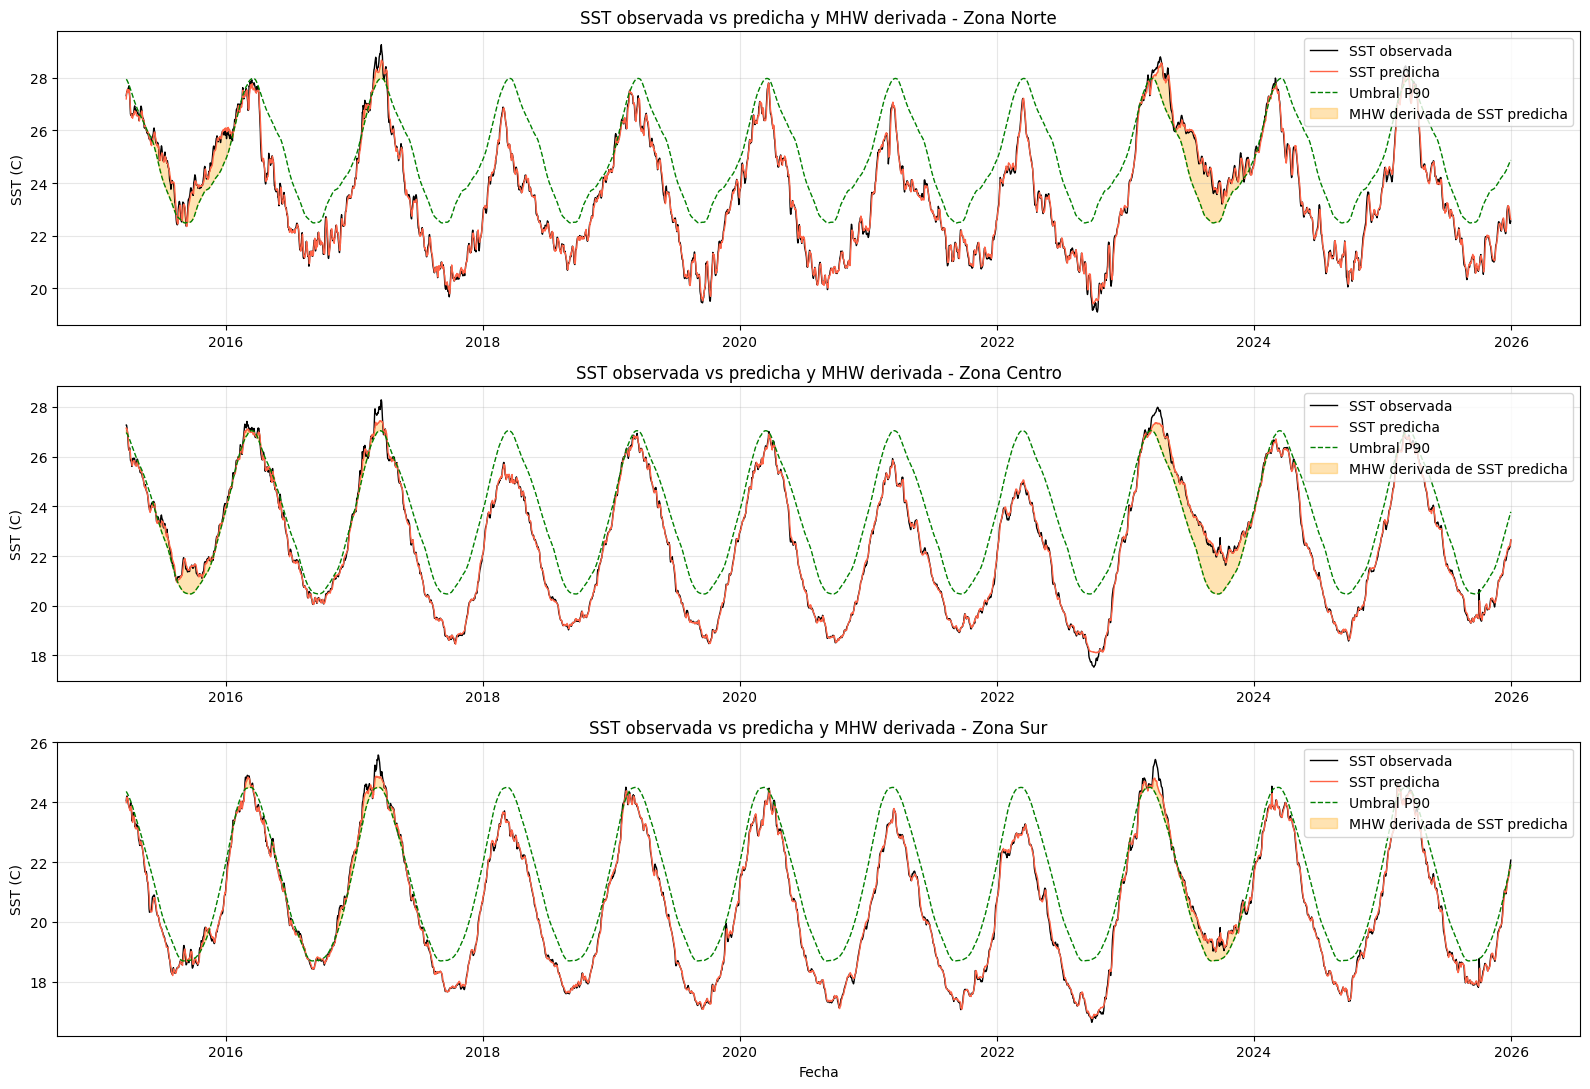

In [ ]:
# Serie observada vs predicha para el periodo de prueba
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=False)

for ax, zona in zip(axes, ['Norte', 'Centro', 'Sur']):
    sub = predicciones_mejor_modelo[predicciones_mejor_modelo['zona'] == zona]
    ax.plot(sub['fecha'], sub['sst_observada'], label='SST observada', color='black', linewidth=1)
    ax.plot(sub['fecha'], sub['sst_predicha'], label='SST predicha', color='tomato', linewidth=1)
    ax.plot(sub['fecha'], sub['umbral_p90'], label='Umbral P90', color='green', linestyle='--', linewidth=1)
    ax.fill_between(sub['fecha'], sub['sst_predicha'], sub['umbral_p90'],
                    where=sub['mhw_predicha'].astype(bool), color='orange', alpha=0.3,
                    label='MHW derivada de SST predicha')
    ax.set_title(f'SST observada vs predicha y MHW derivada - Zona {zona}')
    ax.set_ylabel('SST (C)')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

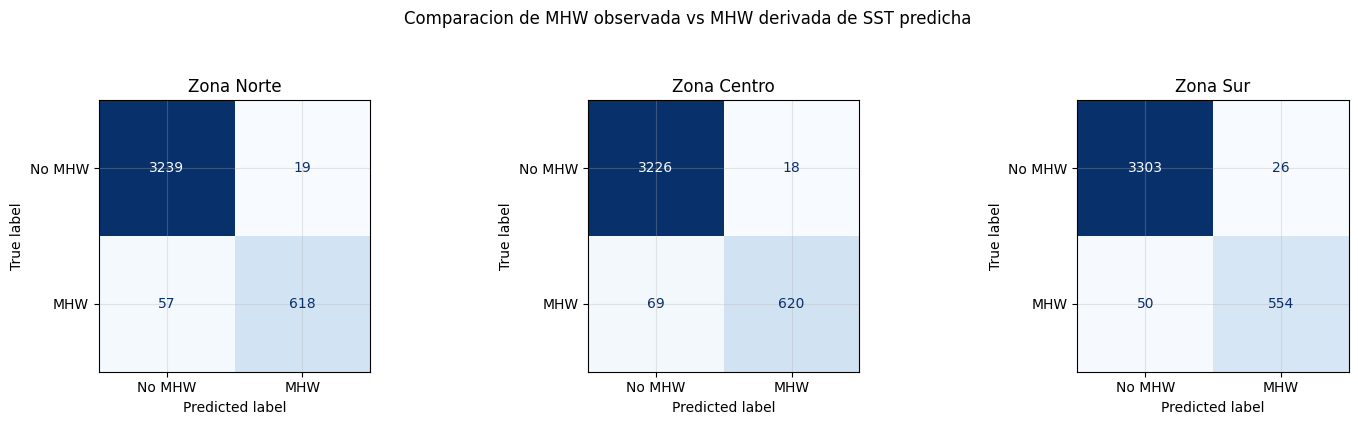

In [ ]:
# Matrices de confusion: MHW observada vs MHW derivada desde SST predicha
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, zona in zip(axes, ['Norte', 'Centro', 'Sur']):
    sub = predicciones_mejor_modelo[predicciones_mejor_modelo['zona'] == zona]
    ConfusionMatrixDisplay.from_predictions(
        sub['mhw_observada'].astype(int),
        sub['mhw_predicha'].astype(int),
        labels=[0, 1], display_labels=['No MHW', 'MHW'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Zona {zona}')

plt.suptitle('Comparacion de MHW observada vs MHW derivada de SST predicha', y=1.05)
plt.tight_layout()
plt.show()

## 13. Identificacion final de olas de calor marinas observadas

Esta parte mantiene la identificacion fisica con la SST observada. Sirve como referencia para comparar contra la deteccion obtenida desde la SST predicha.

In [ ]:
# Tabla final de eventos observados por zona
columnas_eventos = [
    'zona', 'evento_id_zona', 'fecha_inicio', 'fecha_fin', 'duracion_dias',
    'fecha_pico', 'sst_pico', 'intensidad_maxima', 'intensidad_media',
    'intensidad_acumulada', 'categoria_intensidad', 'categoria_duracion'
]

eventos_final = eventos_mhw[columnas_eventos].sort_values(['zona', 'fecha_inicio']).copy()
display(eventos_final)

print('Numero de eventos observados por zona:')
print(eventos_final.groupby('zona').size().sort_index())

,zona,evento_id_zona,fecha_inicio,fecha_fin,duracion_dias,fecha_pico,sst_pico,intensidad_maxima,intensidad_media,intensidad_acumulada,categoria_intensidad,categoria_duracion
0,Centro,1,1992-03-30,1992-04-17,19,1992-04-10,26.739109,1.310035,1.130918,21.487448,I - Baja (<25 C dia),Corta (5-29 dias)
1,Centro,2,1992-04-28,1992-05-11,14,1992-05-08,26.111694,1.833747,1.426022,19.964309,I - Baja (<25 C dia),Corta (5-29 dias)
2,Centro,3,1997-05-04,1998-06-15,408,1997-12-12,25.583363,3.815134,2.587326,1055.629080,IV - Extrema (>=200 C dia),Larga (>=100 dias)
3,Centro,4,1998-07-05,1998-07-13,9,1998-07-09,23.152332,1.966913,1.856295,16.706654,I - Baja (<25 C dia),Corta (5-29 dias)
4,Centro,5,1998-07-20,1998-08-12,24,1998-07-29,22.537674,2.131320,1.759846,42.236314,II - Moderada (25-99 C dia),Corta (5-29 dias)
...,...,...,...,...,...,...,...,...,...,...,...,...
135,Sur,37,2023-02-08,2023-05-09,91,2023-03-27,25.426376,1.889297,1.216681,110.717939,III - Alta (100-199 C dia),Media (30-99 dias)
136,Sur,38,2023-06-05,2023-11-14,163,2023-09-27,19.813852,1.890134,1.257803,205.021834,IV - Extrema (>=200 C dia),Larga (>=100 dias)
137,Sur,39,2023-11-20,2023-12-04,15,2023-11-27,20.604275,1.213538,1.067596,16.013938,I - Baja (<25 C dia),Corta (5-29 dias)
138,Sur,40,2025-02-09,2025-02-20,12,2025-02-13,24.663975,1.256748,1.023632,12.283588,I - Baja (<25 C dia),Corta (5-29 dias)


Numero de eventos observados por zona:
zona
Centro        35
Norte         35
Peru_total    29
Sur           41
dtype: int64


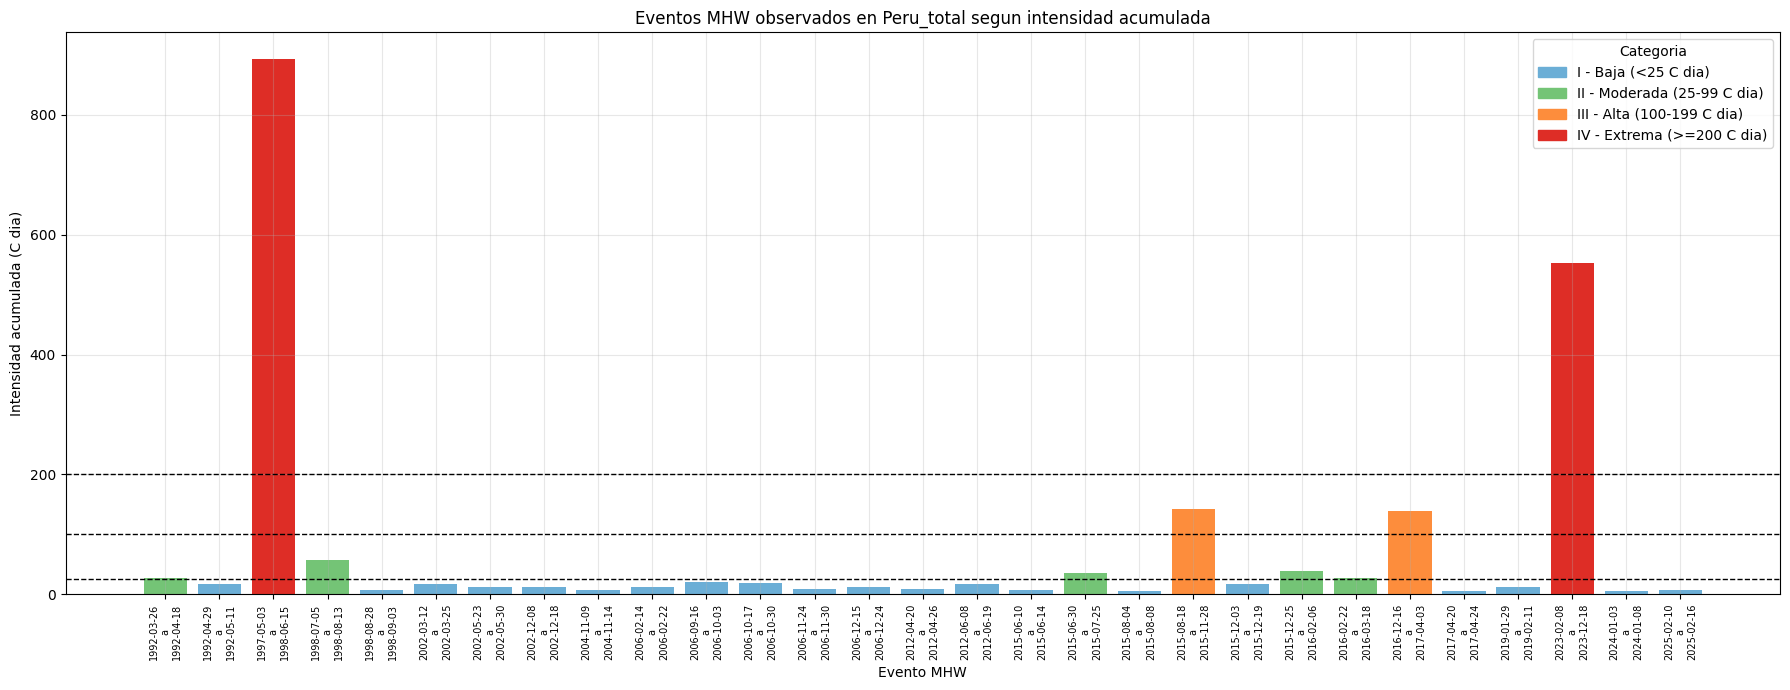

In [ ]:
# Grafico de eventos observados en Peru_total, comparable con el avance inicial del proyecto
zona_eventos = 'Peru_total'
df_plot = eventos_mhw[eventos_mhw['zona'] == zona_eventos].copy().sort_values('fecha_inicio')

mapa_colores = {
    'I - Baja (<25 C dia)': '#6baed6',
    'II - Moderada (25-99 C dia)': '#74c476',
    'III - Alta (100-199 C dia)': '#fd8d3c',
    'IV - Extrema (>=200 C dia)': '#de2d26',
}

if len(df_plot) > 0:
    df_plot['etiqueta_evento'] = (
        df_plot['fecha_inicio'].dt.strftime('%Y-%m-%d') + '\na\n' +
        df_plot['fecha_fin'].dt.strftime('%Y-%m-%d')
    )
    colores = df_plot['categoria_intensidad'].map(mapa_colores).fillna('gray')

    plt.figure(figsize=(18, 7))
    plt.bar(df_plot['etiqueta_evento'], df_plot['intensidad_acumulada'], color=colores)
    plt.axhline(25, linestyle='--', linewidth=1, color='black')
    plt.axhline(100, linestyle='--', linewidth=1, color='black')
    plt.axhline(200, linestyle='--', linewidth=1, color='black')
    plt.title('Eventos MHW observados en Peru_total segun intensidad acumulada')
    plt.xlabel('Evento MHW')
    plt.ylabel('Intensidad acumulada (C dia)')
    plt.xticks(rotation=90, fontsize=7)
    leyenda = [mpatches.Patch(color=v, label=k) for k, v in mapa_colores.items()]
    plt.legend(handles=leyenda, title='Categoria', loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print('No hay eventos para Peru_total con los parametros actuales.')

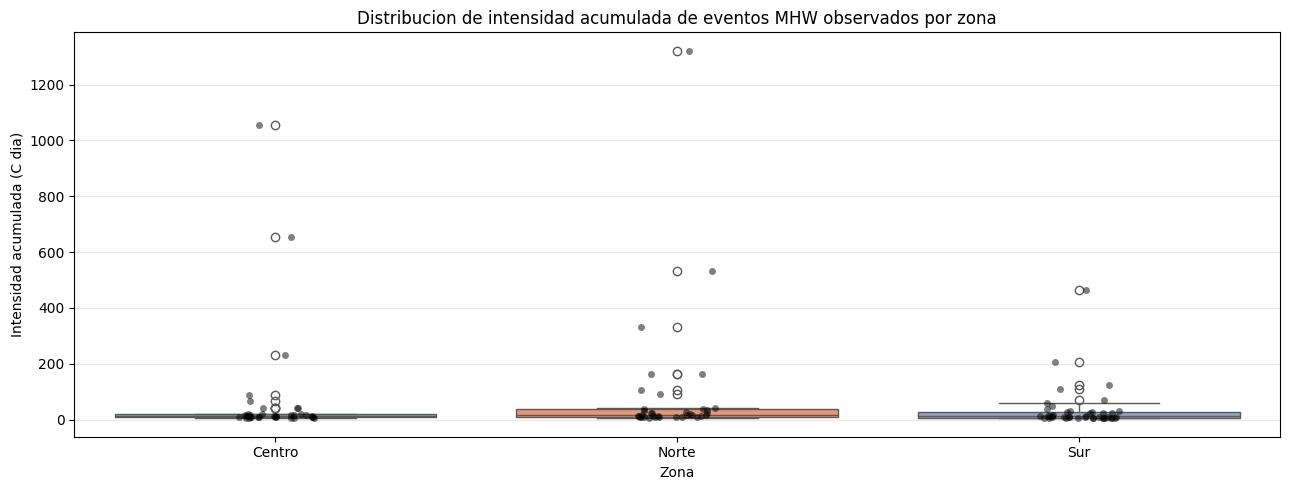

In [ ]:
# Comparacion de intensidad acumulada observada por zona
plt.figure(figsize=(13, 5))
sns.boxplot(data=eventos_mhw[eventos_mhw['zona'].isin(['Norte', 'Centro', 'Sur'])],
            x='zona', y='intensidad_acumulada', palette='Set2')
sns.stripplot(data=eventos_mhw[eventos_mhw['zona'].isin(['Norte', 'Centro', 'Sur'])],
              x='zona', y='intensidad_acumulada', color='black', alpha=0.5)
plt.title('Distribucion de intensidad acumulada de eventos MHW observados por zona')
plt.xlabel('Zona')
plt.ylabel('Intensidad acumulada (C dia)')
plt.tight_layout()
plt.show()

## 14. Interpretacion de la comparacion por zonas

Usa esta seccion para redactar los resultados luego de ejecutar el notebook:

- Si una zona obtiene menor RMSE, significa que la SST de esa zona fue predicha con menor error promedio.
- Si una zona obtiene buen RMSE pero bajo F1 MHW derivado, significa que pequenos errores de temperatura cerca del umbral P90 pueden afectar la deteccion de eventos.
- Si el recall MHW derivado es alto, la SST predicha permite recuperar buena parte de los dias MHW observados.
- Si la precision MHW derivada es baja, el metodo estaria generando falsas alarmas de MHW.
- La division Norte/Centro/Sur permite evaluar si el modelo funciona mejor en zonas con senales termicas mas marcadas o con menor variabilidad local.

## 15. Contribuciones esperadas del proyecto

1. **Prediccion ambiental:** estima la SST diaria en la costa peruana usando Random Forest Regressor y variables temporales/rezagadas.
2. **Deteccion metodologica:** aplica Hobday sobre SST observada y sobre SST predicha, separando claramente prediccion de temperatura e identificacion de MHW.
3. **Comparacion regional:** evalua diferencias entre zona Norte, Centro y Sur para identificar donde el modelo predice mejor la SST.
4. **Gestion y monitoreo:** genera una base reproducible para anticipar condiciones termicas que podrian derivar en olas de calor marinas.

## 16. Conclusiones para completar despues de ejecutar

Completar los valores numericos despues de correr todo el notebook:

1. Se identificaron **N eventos MHW observados** en el dominio `Peru_total` durante 1990-2025. Los anos con mayor numero de dias MHW fueron **AAAA, AAAA y AAAA**.
2. La comparacion zonal mostro que la zona **Norte/Centro/Sur** presento mayor frecuencia o severidad de eventos observados, segun los indicadores de dias MHW e intensidad acumulada.
3. En la prediccion de SST, el mejor desempeno se obtuvo en la zona **X** con el modelo **RF_X**, alcanzando un RMSE de **X.XX C** y un R2 de **X.XX**.
4. Al aplicar Hobday sobre la SST predicha, la deteccion MHW obtuvo un F1 de **X.XX** en la zona **X**, mostrando que la calidad de deteccion depende directamente del error de prediccion de temperatura.
5. Como limitacion, pequenos errores en SST cerca del umbral P90 pueden cambiar la clasificacion de un dia como MHW o no MHW. Ademas, el promedio espacial por zona puede ocultar procesos locales de menor escala.

## 17. Exportacion de resultados

Se guardan las tablas principales para usarlas luego en Canva, en el informe o en el dashboard.

In [ ]:
archivos_exportar = {
    'mhw_diario_zonas_observado.csv': mhw_diario,
    'eventos_mhw_zonas_observado.csv': eventos_mhw,
    'resumen_anual_zonas_observado.csv': resumen_anual,
    'dataset_ml_prediccion_sst.csv': df_ml,
    'comparacion_rf_regressor_sst_zonas.csv': tabla_modelos,
    'mejores_modelos_sst_por_zona.csv': mejores_por_zona,
    'predicciones_test_sst_mejor_modelo.csv': predicciones_mejor_modelo,
    'diario_mhw_predicho_mejor_modelo.csv': diario_predicho_mejor,
    'eventos_mhw_predichos_mejor_modelo.csv': eventos_predichos_mejor,
    'importancias_mejores_modelos_sst.csv': importancias_mejores,
}

for nombre, df in archivos_exportar.items():
    ruta = OUT_DIR / nombre
    df.to_csv(ruta, index=False)
    print('Guardado:', ruta)

Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/mhw_diario_zonas_observado.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/eventos_mhw_zonas_observado.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/resumen_anual_zonas_observado.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/dataset_ml_prediccion_sst.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/comparacion_rf_regressor_sst_zonas.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/mejores_modelos_sst_por_zona.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/predicciones_test_sst_mejor_modelo.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/diario_mhw_predicho_mejor_modelo.csv
Guardado: /content/drive/MyDrive/DATOS_PROYECTO/RESULTADOS_INTEGRADOR_FINAL/eventos_mhw_predichos_mejor_modelo.csv
Gu